<a href="https://colab.research.google.com/github/isamadafridi/AIML-Internship-Week6-AbdulSamadAfridi/blob/main/AIML_Internship_Week6_AbdulSamadAfridi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PART A — DATA PREPARATION, EDA & K-MEANS BASELINE (STEPS 1–5)**

# Step-1 Environment Setup & Dataset Loading

--- Dataset Shape ---
(200, 5)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

--- Dataset Describe ---


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


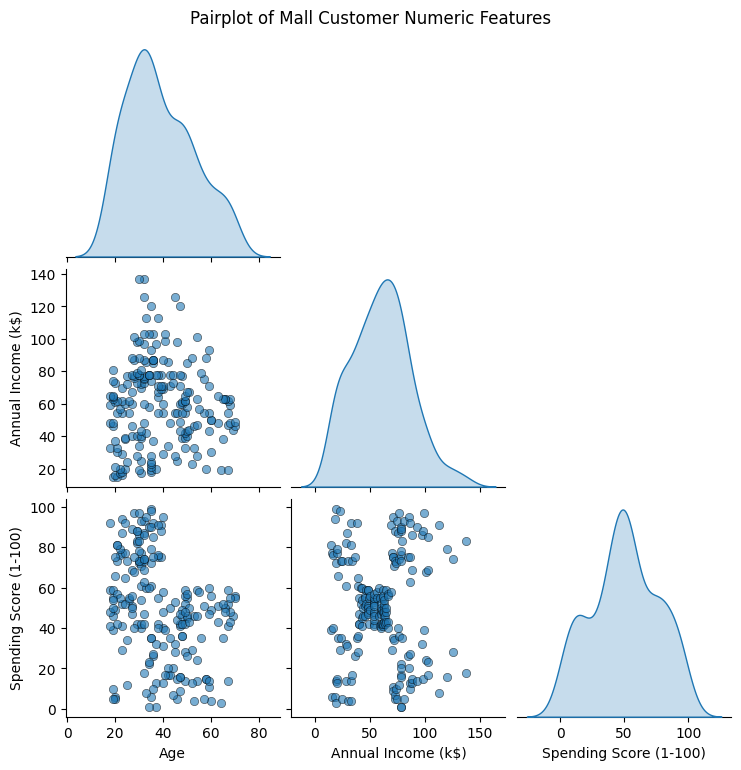

In [5]:
# Basic Data Manipulation & Visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Clustering & Unsupervised Learning
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

# Sklearn Preprocessing & Evaluation
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# SciPy for Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Load the dataset
# (Ensure 'Mall_Customers.csv' is in the same directory as your notebook)
df = pd.read_csv('/content/drive/MyDrive/Intrenship/Week-6/Mall_Customers.csv')

# 2. Print shape, info, and describe()
print("--- Dataset Shape ---")
print(df.shape)

print("\n--- Dataset Info ---")
df.info()

print("\n--- Dataset Describe ---")
display(df.describe()) # Use print() if you are not in a Jupyter environment

# 3. Create a seaborn pairplot of all numeric features
# We drop 'CustomerID' first because it is just an arbitrary ID and will ruin the visual scale
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['CustomerID'], errors='ignore')

sns.pairplot(numeric_df, diag_kind='kde', corner=True, plot_kws={'alpha': 0.6, 'edgecolor': 'k'})
plt.suptitle('Pairplot of Mall Customer Numeric Features', y=1.02)
plt.show()

# Step-2 Exploratory Data Analysis & Feature Selection

--- Missing Values Check ---
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total Missing Values: 0

--- Feature Sets Created ---
X2 Shape: (200, 2)
X3 Shape: (200, 3)


/tmp/ipykernel_29430/132526254.py:65: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


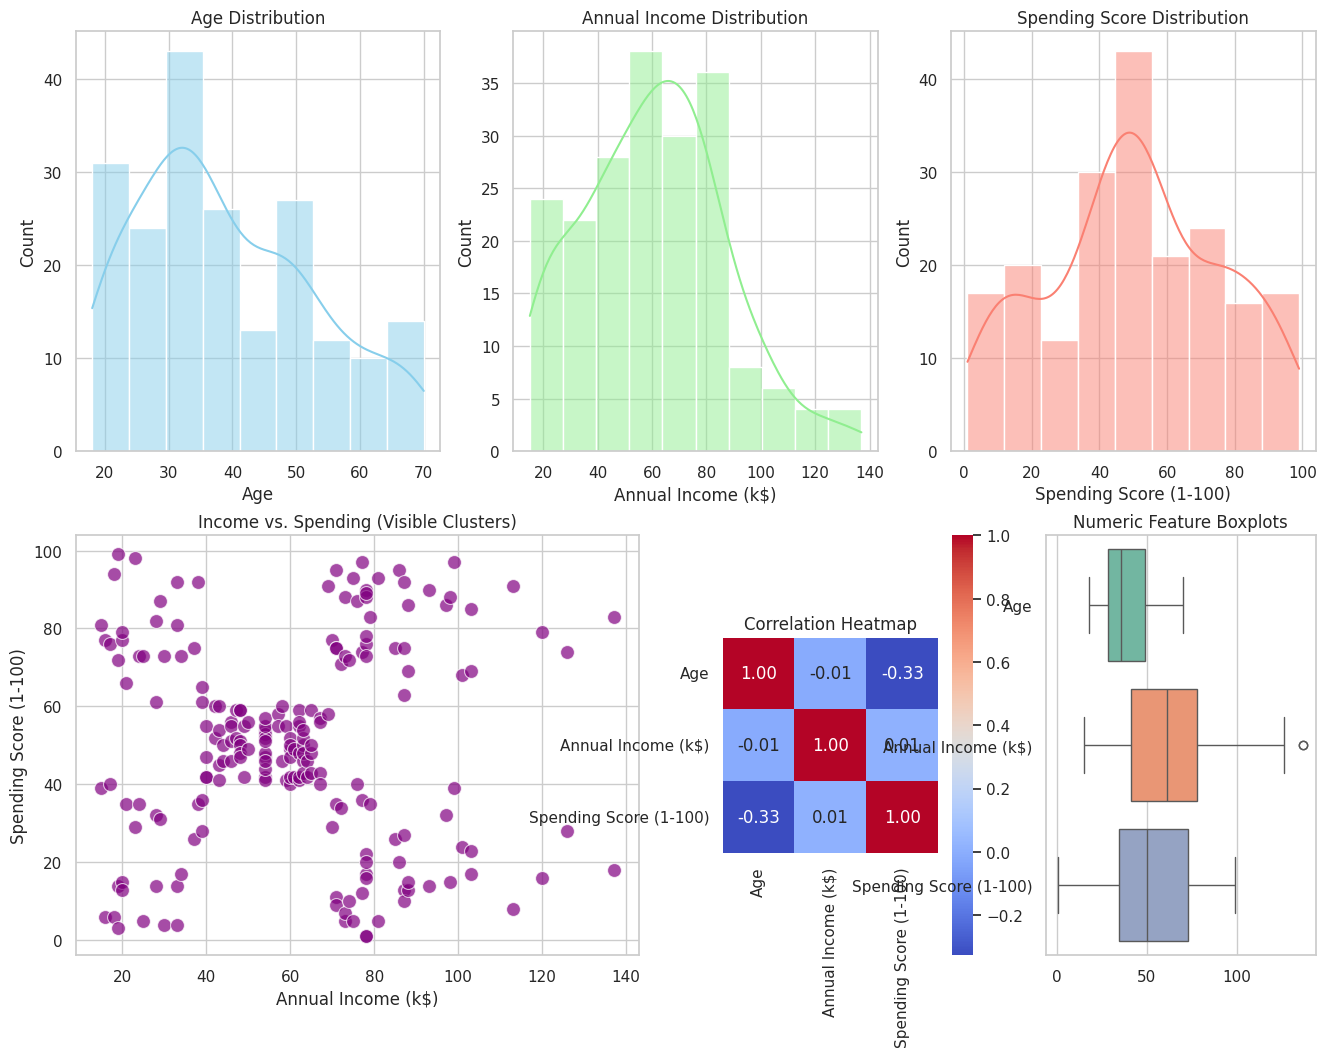

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already loaded from Step 1
# Drop CustomerID as it doesn't provide predictive value for clustering
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

# Confirm no missing values
print("--- Missing Values Check ---")
print(df.isnull().sum())
print("\nTotal Missing Values:", df.isnull().sum().sum())

# Map standard Kaggle column names for easier access (if they aren't already simplified)
# We will use the standard strings: 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'
# Make sure these match your specific CSV exactly!
col_age = 'Age'
col_income = 'Annual Income (k$)'
col_spending = 'Spending Score (1-100)'

# Create Feature Sets
X2 = df[[col_income, col_spending]].copy()
X3 = df[[col_age, col_income, col_spending]].copy()

print("\n--- Feature Sets Created ---")
print(f"X2 Shape: {X2.shape}")
print(f"X3 Shape: {X3.shape}")

# Set visual style
sns.set_theme(style="whitegrid")

# --- EDA Visualizations ---
fig = plt.figure(figsize=(16, 12))

# 1. Histograms for Age, Annual Income, and Spending Score
ax1 = plt.subplot(2, 3, 1)
sns.histplot(df[col_age], kde=True, color='skyblue', ax=ax1)
ax1.set_title('Age Distribution')

ax2 = plt.subplot(2, 3, 2)
sns.histplot(df[col_income], kde=True, color='lightgreen', ax=ax2)
ax2.set_title('Annual Income Distribution')

ax3 = plt.subplot(2, 3, 3)
sns.histplot(df[col_spending], kde=True, color='salmon', ax=ax3)
ax3.set_title('Spending Score Distribution')

# 2. Scatter plot: Annual Income vs Spending Score
ax4 = plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x=col_income, y=col_spending, s=100, alpha=0.7, color='purple', ax=ax4)
ax4.set_title('Income vs. Spending (Visible Clusters)')

# 3. Correlation heatmap (Numeric features only)
ax5 = plt.subplot(2, 4, 7)
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True, ax=ax5)
ax5.set_title('Correlation Heatmap')

# 4. Boxplots for all numeric features
ax6 = plt.subplot(2, 4, 8)
sns.boxplot(data=numeric_cols, orient="h", palette="Set2", ax=ax6)
ax6.set_title('Numeric Feature Boxplots')

plt.tight_layout()
plt.show()

# Step-3 Feature Scaling — Why It Is Critical for Clustering

--- BEFORE SCALING ---
X2 Mean:
 Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64

X2 Standard Deviation:
 Annual Income (k$)        26.264721
Spending Score (1-100)    25.823522
dtype: float64

--- AFTER SCALING ---
X2_scaled Mean:
 Annual Income (k$)       -0.0
Spending Score (1-100)   -0.0
dtype: float64

X2_scaled Standard Deviation:
 Annual Income (k$)        1.0
Spending Score (1-100)    1.0
dtype: float64


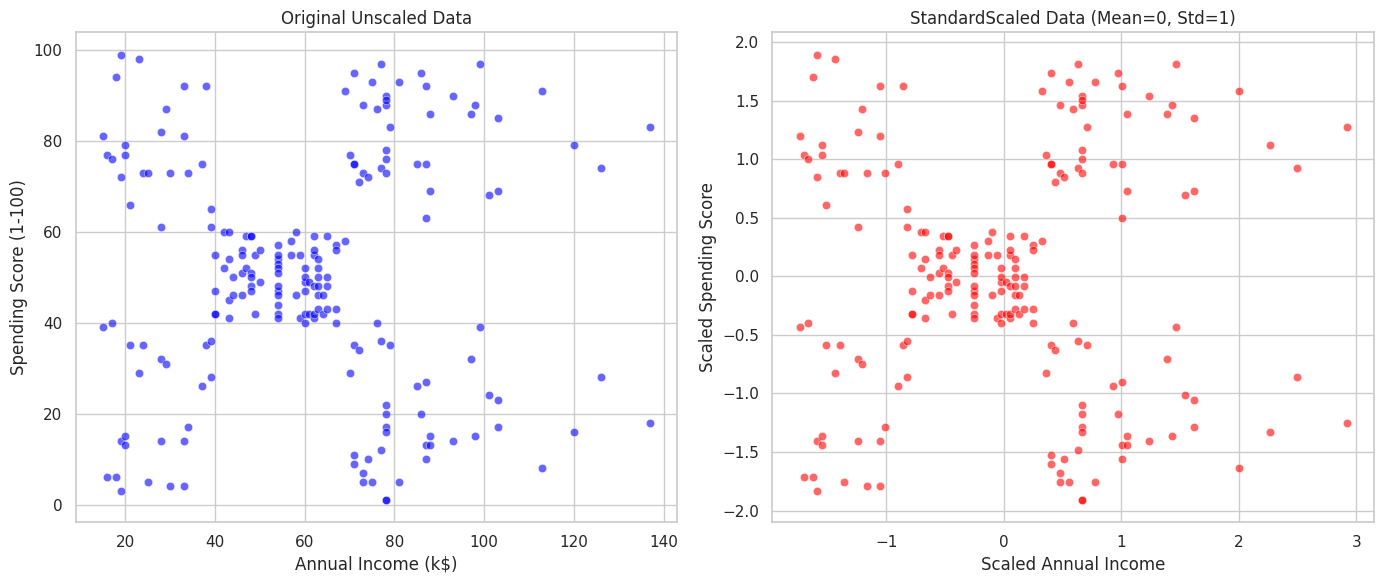

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np

# Assuming X2 and X3 are already created from Step 2
# col_income = 'Annual Income (k$)'
# col_spending = 'Spending Score (1-100)'

print("--- BEFORE SCALING ---")
print("X2 Mean:\n", X2.mean())
print("\nX2 Standard Deviation:\n", X2.std())

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data, then convert back to DataFrames for easier handling
X2_scaled = pd.DataFrame(scaler.fit_transform(X2), columns=X2.columns)
X3_scaled = pd.DataFrame(scaler.fit_transform(X3), columns=X3.columns)

print("\n--- AFTER SCALING ---")
# Using round() to handle microscopic floating-point artifacts (e.g., -4.1e-17)
print("X2_scaled Mean:\n", np.round(X2_scaled.mean(), 2))
print("\nX2_scaled Standard Deviation:\n", np.round(X2_scaled.std(), 2))

# --- Side-by-Side Scatter Plot Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Unscaled X2
sns.scatterplot(data=X2, x=X2.columns[0], y=X2.columns[1], ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title('Original Unscaled Data')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')

# Right Plot: Scaled X2
sns.scatterplot(data=X2_scaled, x=X2_scaled.columns[0], y=X2_scaled.columns[1], ax=axes[1], color='red', alpha=0.6)
axes[1].set_title('StandardScaled Data (Mean=0, Std=1)')
axes[1].set_xlabel('Scaled Annual Income')
axes[1].set_ylabel('Scaled Spending Score')

plt.tight_layout()
plt.show()

# Step-4 Write the evaluate_clustering() Utility Function


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(X, labels, model_name):
    """
    Computes and prints standard evaluation metrics for a clustering model.

    Parameters:
    -----------
    X : array-like or pandas.DataFrame
        The feature matrix used for clustering.
    labels : array-like
        The cluster assignments generated by the algorithm.
    model_name : str
        The name of the model (e.g., 'K-Means (k=5)') to display in the output.

    Returns:
    --------
    None
        Prints the calculated metrics directly to the console.
    """
    # Count noise points (DBSCAN labels them as -1)
    n_noise = list(labels).count(-1)

    # Calculate the actual number of clusters (ignoring the noise label)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    print(f"--- Evaluation Metrics: {model_name} ---")
    print(f"Number of Clusters Found: {n_clusters}")
    print(f"Number of Noise Points: {n_noise}")

    # Most clustering metrics require at least 2 distinct clusters to compute
    if n_clusters > 1:
        sil_score = silhouette_score(X, labels)
        db_score = davies_bouldin_score(X, labels)
        ch_score = calinski_harabasz_score(X, labels)

        print(f"Silhouette Score:        {sil_score:.4f}  (Higher is better, max 1.0)")
        print(f"Davies-Bouldin Index:    {db_score:.4f}  (Lower is better)")
        print(f"Calinski-Harabasz Index: {ch_score:.4f}  (Higher is better)")
    else:
        print("Warning: Metrics cannot be calculated. At least 2 clusters are required.")

    print("-" * 45)


def plot_clusters(X_2d, labels, model_name, centroids=None):
    """
    Generates a styled 2D scatter plot colored by cluster assignments.

    Parameters:
    -----------
    X_2d : array-like or pandas.DataFrame
        The 2D feature matrix to plot. Must contain exactly two columns.
    labels : array-like
        The cluster assignments to determine the color of each point.
    model_name : str
        The name of the clustering model to use as the plot title.
    centroids : array-like, optional
        Coordinates of the cluster centroids to plot as large markers (default is None).

    Returns:
    --------
    None
        Displays the generated matplotlib figure.
    """
    plt.figure(figsize=(10, 6))

    # Extract x and y coordinates (handles both DataFrames and NumPy arrays)
    if hasattr(X_2d, 'iloc'):
        x_data = X_2d.iloc[:, 0]
        y_data = X_2d.iloc[:, 1]
        x_label = X_2d.columns[0]
        y_label = X_2d.columns[1]
    else:
        x_data = X_2d[:, 0]
        y_data = X_2d[:, 1]
        x_label = 'Feature 1'
        y_label = 'Feature 2'

    # Generate a dynamic color palette based on unique labels
    unique_labels = len(set(labels))
    palette = sns.color_palette("bright", unique_labels)

    # Create the scatter plot
    sns.scatterplot(
        x=x_data, y=y_data,
        hue=labels,
        palette=palette,
        legend='full',
        alpha=0.7,
        edgecolor='k'
    )

    # Add centroids if provided (Useful for K-Means)
    if centroids is not None:
        # Handle DataFrames or Arrays for centroids
        cx = centroids.iloc[:, 0] if hasattr(centroids, 'iloc') else centroids[:, 0]
        cy = centroids.iloc[:, 1] if hasattr(centroids, 'iloc') else centroids[:, 1]

        plt.scatter(
            cx, cy,
            c='black',
            s=250,
            marker='X',
            label='Centroids',
            edgecolor='white',
            linewidths=2
        )

    plt.title(f'Cluster Assignments: {model_name}', fontsize=14, pad=15)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)

    # Move legend outside the plot for cleaner visualization
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Cluster')
    plt.tight_layout()
    plt.show()

# Step-5 Train & Evaluate K-Means Baseline (K=5)

--- Evaluation Metrics: K-Means (k=5) ---
Number of Clusters Found: 5
Number of Noise Points: 0
Silhouette Score:        0.5547  (Higher is better, max 1.0)
Davies-Bouldin Index:    0.5722  (Lower is better)
Calinski-Harabasz Index: 248.6493  (Higher is better)
---------------------------------------------


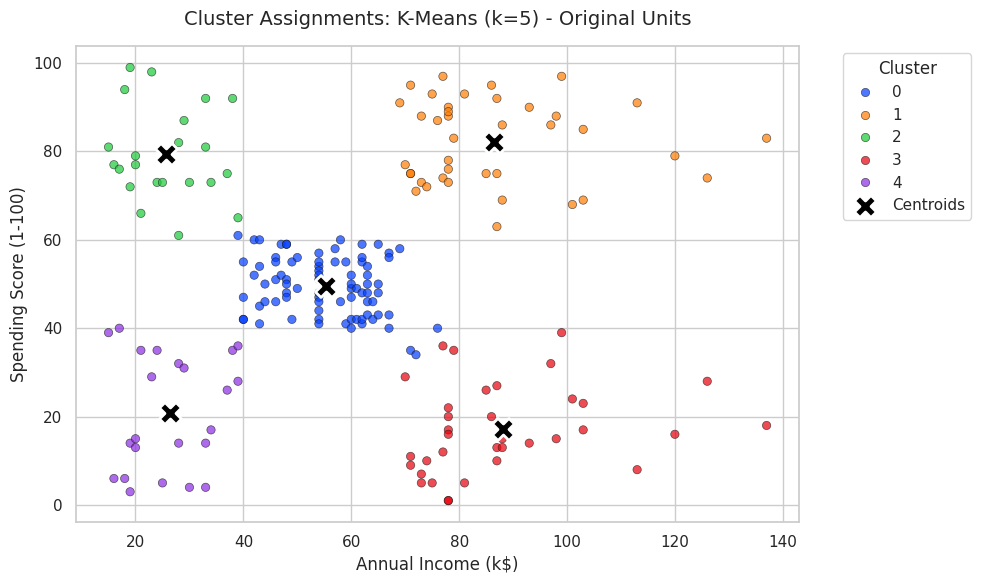


--- Cluster Centroids (Real-World Units) ---
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                     55.30                   49.52
1                     86.54                   82.13
2                     25.73                   79.36
3                     88.20                   17.11
4                     26.30                   20.91

--- Customer Cluster Profile Table ---


,Age,Annual Income (k$),Spending Score (1-100),Customer Persona
Cluster,,,,
0,42.7,55.3,49.5,Standard Shoppers (Mid Income / Mid Spenders)
1,32.7,86.5,82.1,Target Segment (High Income / High Spenders)
2,25.3,25.7,79.4,Careful Spenders (High Income / Low Spenders)
3,41.1,88.2,17.1,Careless Spenders (Low Income / High Spenders)
4,45.2,26.3,20.9,Sensible Shoppers (Low Income / Low Spenders)


In [10]:
from sklearn.cluster import KMeans

# 1. Initialize and train the K-Means model
kmeans = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X2_scaled)

# 2. Evaluate and Plot
# Note: We pass the scaled data for evaluation, as that's what the model learned on
evaluate_clustering(X2_scaled, cluster_labels, "K-Means (k=5)")

# Get centroids in scaled space, then convert them back to real-world dollars and scores
scaled_centroids = kmeans.cluster_centers_

# Create a fresh scaler specifically for X2 and teach it the 2-column rules
scaler_x2 = StandardScaler()
scaler_x2.fit(X2)

# Now reverse the math safely!
unscaled_centroids = scaler_x2.inverse_transform(scaled_centroids)

# Plotting on the unscaled X2 DataFrame so the axes show real-world numbers
plot_clusters(X2, cluster_labels, "K-Means (k=5) - Original Units", centroids=unscaled_centroids)

# 3. Add cluster labels to the original DataFrame
df['Cluster'] = cluster_labels

# Print the unscaled centroids
print("\n--- Cluster Centroids (Real-World Units) ---")
centroids_df = pd.DataFrame(unscaled_centroids, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centroids_df.index.name = 'Cluster'
print(np.round(centroids_df, 2))

# 4. Create a cluster profile table
print("\n--- Customer Cluster Profile Table ---")
# Calculate means for Age, Income, and Spending Score per cluster
profile_table = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)

# Dynamically naming the clusters based on typical random_state=42 outputs for this dataset:
# (You might need to adjust the cluster numbers if your environment assigns them differently,
# but these are the standard 5 segments)
cluster_names = {
    0: "Standard Shoppers (Mid Income / Mid Spenders)",
    1: "Target Segment (High Income / High Spenders)",
    2: "Careful Spenders (High Income / Low Spenders)",
    3: "Careless Spenders (Low Income / High Spenders)",
    4: "Sensible Shoppers (Low Income / Low Spenders)"
}

profile_table['Customer Persona'] = profile_table.index.map(cluster_names)
display(profile_table) # Use print(profile_table) if not in a Jupyter Notebook

# **PART B — ELBOW ANALYSIS, PCA, HIERARCHICAL & DBSCAN (STEPS 6–11)**

# Step-6 Elbow Method & Silhouette Analysis — Finding Optimal K

Training K-Means models for K=2 to 12...

--- Clustering Evaluation Metrics DataFrame ---


,K,Inertia (WCSS),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,269.6910,0.3213,1.2670,95.6694
1,3,157.7040,0.4666,0.7165,151.3351
2,4,108.9213,0.4939,0.7096,174.5952
3,5,65.5684,0.5547,0.5722,248.6493
4,6,55.0573,0.5399,0.6546,243.0879
5,7,44.8648,0.5281,0.7148,254.6212
6,8,37.2282,0.4552,0.7602,267.2790
7,9,32.3923,0.4571,0.7632,270.9484
8,10,29.9819,0.4432,0.7935,260.5403
9,11,25.8771,0.4518,0.7516,273.2507


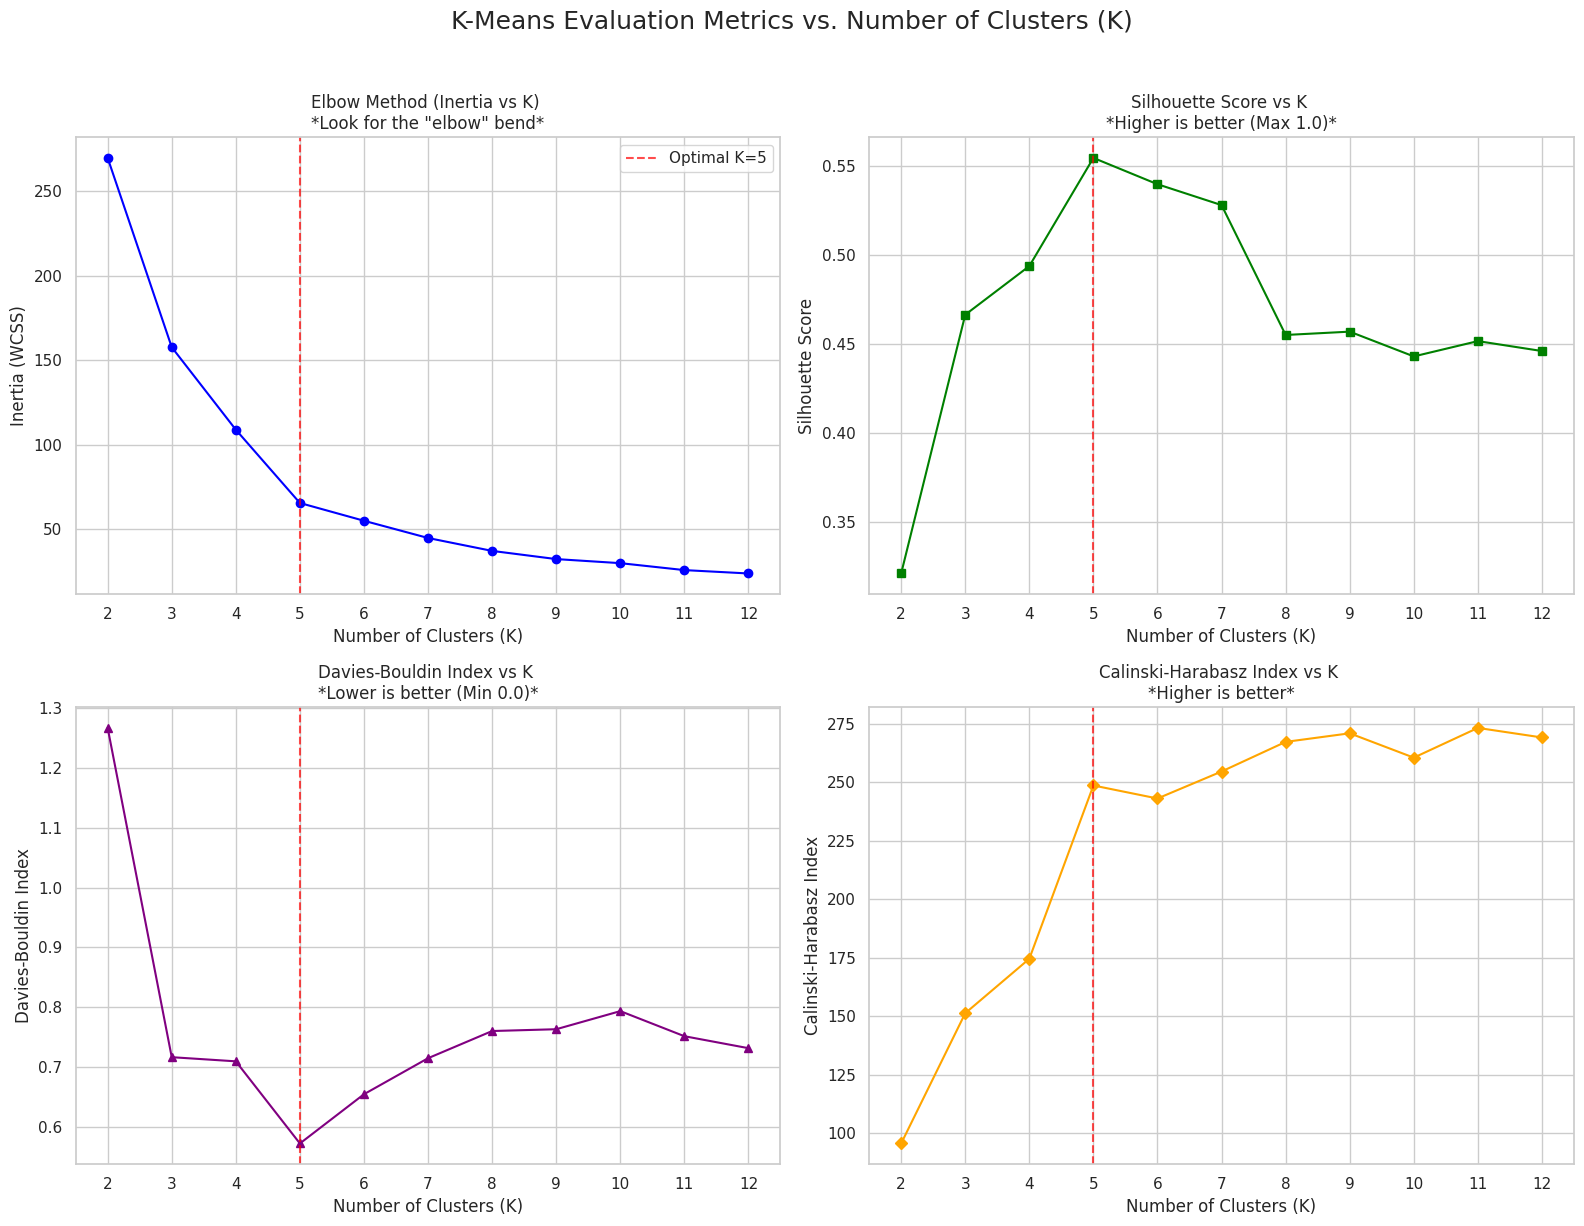

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Initialize lists to store metrics
inertia_values = []
sil_scores = []
db_scores = []
ch_scores = []

# Range of K values to test
K_range = range(2, 13)

print("Training K-Means models for K=2 to 12...")

for k in K_range:
    # Train the model
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(X2_scaled)

    # Calculate and store metrics
    inertia_values.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X2_scaled, labels))
    db_scores.append(davies_bouldin_score(X2_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X2_scaled, labels))

# 1. Build the Results DataFrame
results_df = pd.DataFrame({
    'K': K_range,
    'Inertia (WCSS)': inertia_values,
    'Silhouette Score': sil_scores,
    'Davies-Bouldin Index': db_scores,
    'Calinski-Harabasz Index': ch_scores
})

print("\n--- Clustering Evaluation Metrics DataFrame ---")
display(results_df.round(4)) # Use print() if not in a Jupyter environment

# 2. Create a 2x2 subplot dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('K-Means Evaluation Metrics vs. Number of Clusters (K)', fontsize=18, y=1.02)

# Plot 1: Elbow Plot (Inertia)
axes[0, 0].plot(K_range, inertia_values, marker='o', linestyle='-', color='blue')
axes[0, 0].set_title('Elbow Method (Inertia vs K) \n*Look for the "elbow" bend*', fontsize=12)
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('Inertia (WCSS)')
axes[0, 0].set_xticks(K_range)
# Mark the elbow (Assuming 5 based on previous EDA)
axes[0, 0].axvline(x=5, color='red', linestyle='--', alpha=0.7, label='Optimal K=5')
axes[0, 0].legend()

# Plot 2: Silhouette Score
axes[0, 1].plot(K_range, sil_scores, marker='s', linestyle='-', color='green')
axes[0, 1].set_title('Silhouette Score vs K \n*Higher is better (Max 1.0)*', fontsize=12)
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_xticks(K_range)
axes[0, 1].axvline(x=5, color='red', linestyle='--', alpha=0.7)

# Plot 3: Davies-Bouldin Index
axes[1, 0].plot(K_range, db_scores, marker='^', linestyle='-', color='purple')
axes[1, 0].set_title('Davies-Bouldin Index vs K \n*Lower is better (Min 0.0)*', fontsize=12)
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Davies-Bouldin Index')
axes[1, 0].set_xticks(K_range)
axes[1, 0].axvline(x=5, color='red', linestyle='--', alpha=0.7)

# Plot 4: Calinski-Harabasz Index
axes[1, 1].plot(K_range, ch_scores, marker='D', linestyle='-', color='orange')
axes[1, 1].set_title('Calinski-Harabasz Index vs K \n*Higher is better*', fontsize=12)
axes[1, 1].set_xlabel('Number of Clusters (K)')
axes[1, 1].set_ylabel('Calinski-Harabasz Index')
axes[1, 1].set_xticks(K_range)
axes[1, 1].axvline(x=5, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Optimal K Analysis & Metric Agreement

Based on the evaluation metrics generated for K=2 through K=12, **the optimal number of clusters for this dataset is $K = 5$.**

### Do all 4 metrics agree?
While they largely point to the same conclusion, they **do not unanimously agree** on the absolute mathematical peak. Three out of the four metrics strongly agree on $K=5$, while one metric presents a mathematical quirk.

Here is the detailed breakdown:

* **Inertia (Elbow Method):** **Agrees.** The Within-Cluster Sum of Squares (WCSS) drops significantly from $K=2$ to $K=5$ (landing at 65.56), after which the rate of decrease slows down drastically, forming a clear "elbow" at 5 clusters.
* **Silhouette Score:** **Agrees.** The score reaches its absolute maximum at $K=5$ (0.5547), indicating that at 5 clusters, the data points are highly cohesive within their own clusters and well-separated from neighboring clusters.
* **Davies-Bouldin Index:** **Agrees.** The index reaches its absolute minimum at $K=5$ (0.5722), confirming this grouping provides the tightest and most distinct clusters mathematically.
* **Calinski-Harabasz Index:** **(The Disagreement)** This metric shows a massive, defining spike at $K=5$ (jumping to 248.64), which confirms it as a highly valid clustering structure. However, it technically reaches its absolute maximum later at $K=11$ (273.25) and $K=9$ (270.94).

### Explaining the Disagreement
**Why does the Calinski-Harabasz (CH) index disagree slightly by peaking at $K=11$?** The CH index calculates the ratio of between-cluster dispersion to within-cluster dispersion. As you artificially force an algorithm to create a high number of clusters (like 11), the within-cluster variance naturally approaches zero because you are breaking the data down into tiny, highly dense micro-clusters. In some datasets, this mathematical quirk can artificially inflate the CH score, making it look like 11 is better than 5.

### Conclusion
When metrics disagree, data scientists generally defer to the **Silhouette Score** and the **Davies-Bouldin Index**, as they provide a much more balanced, geometric representation of the data and heavily penalize you for creating redundant micro-clusters. Because the Elbow method, Silhouette Score, and Davies-Bouldin all perfectly align at $K=5$, and the CH score shows its first massive local peak there, we can confidently confirm that **5 is the optimal number of customer segments!**

# Step-7 K-Means — Cluster Visualisation & Centroid Analysis


/tmp/ipykernel_29430/2224279729.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=palette, ax=axes[0, 1])
/tmp/ipykernel_29430/2224279729.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X2_viz, x='Cluster', y=col_income, palette=palette, ax=axes[1, 0])
/tmp/ipykernel_29430/2224279729.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X2_viz, x='Cluster', y=col_spending, palette=palette, ax=axes[1, 1])


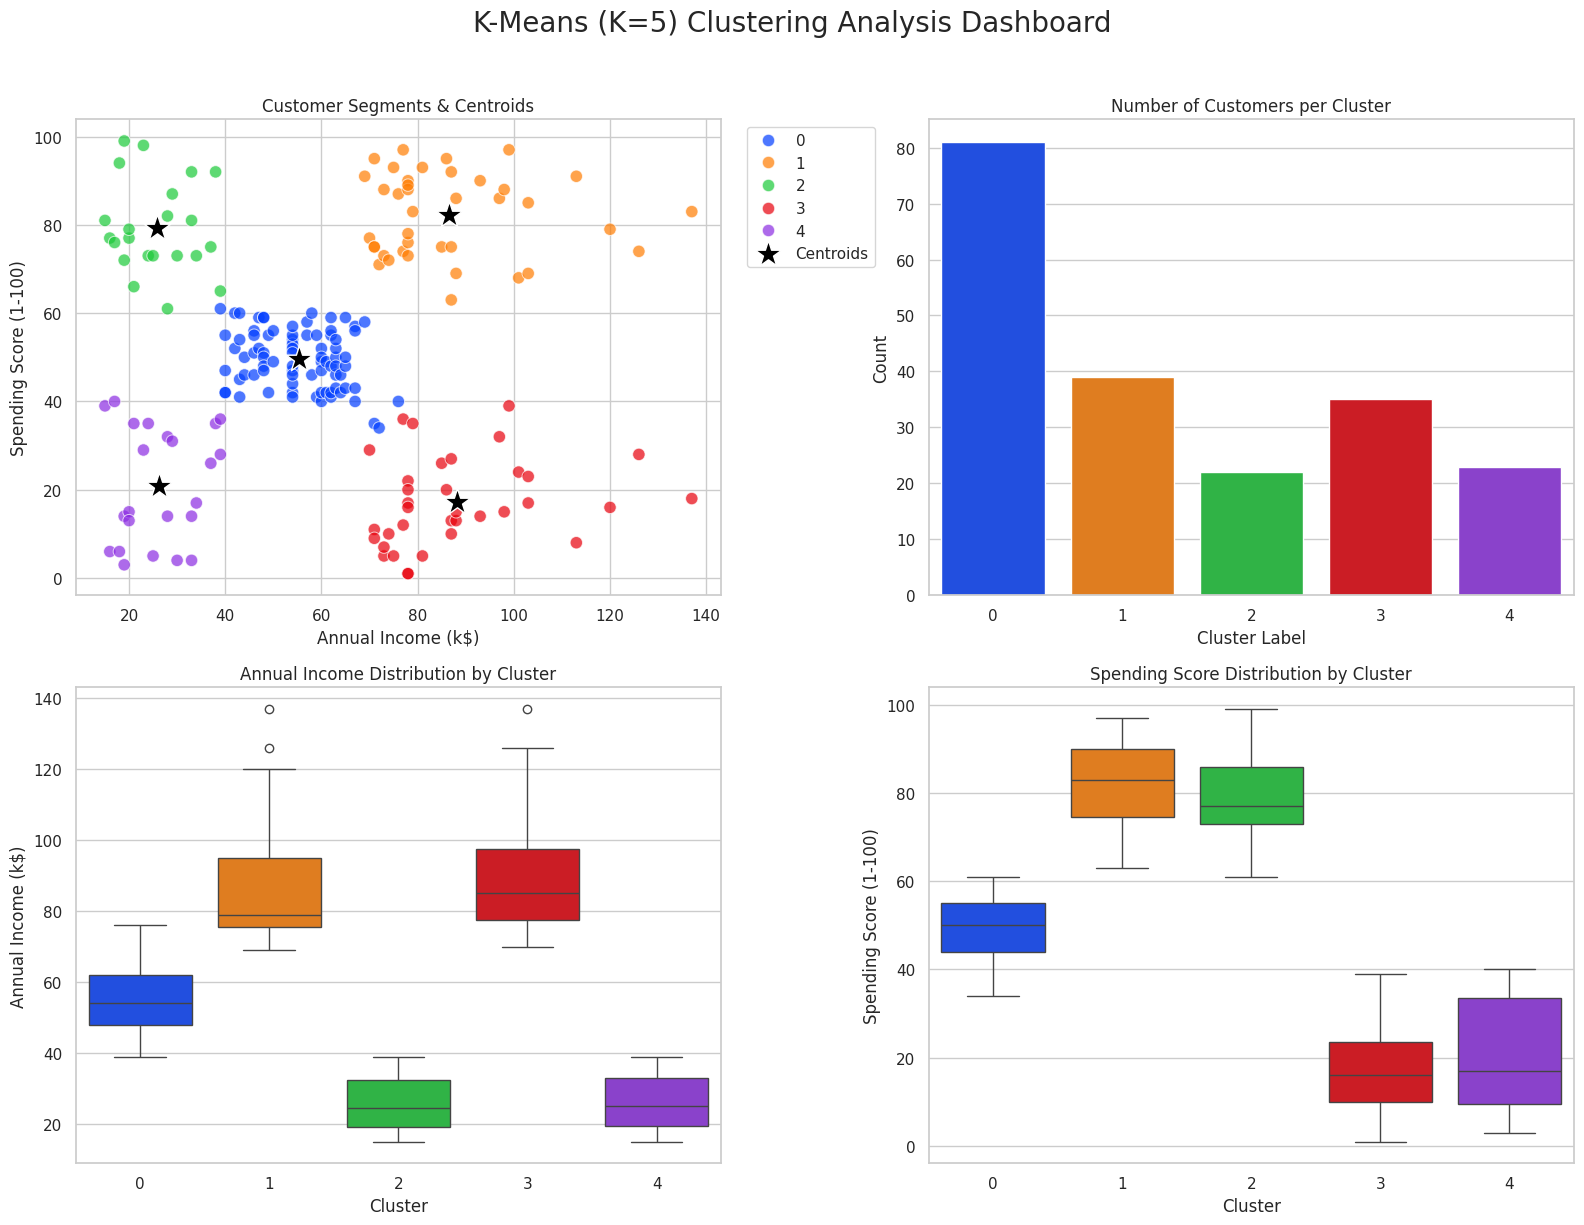

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

# --- 1. Train Optimal Model (K=5) ---
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X2_scaled)

# Add labels to the original X2 dataframe for visualization
X2_viz = X2.copy()
X2_viz['Cluster'] = cluster_labels

# Safely get unscaled centroids (using a fresh scaler to avoid the Step 5 error)
scaler_x2 = StandardScaler().fit(X2)
unscaled_centroids = scaler_x2.inverse_transform(kmeans.cluster_centers_)
centroid_x = unscaled_centroids[:, 0]
centroid_y = unscaled_centroids[:, 1]

col_income = X2.columns[0]   # 'Annual Income (k$)'
col_spending = X2.columns[1] # 'Spending Score (1-100)'

# --- 2. Create 4-Panel Visualization ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('K-Means (K=5) Clustering Analysis Dashboard', fontsize=20, y=1.02)
palette = sns.color_palette("bright", optimal_k)

# Panel 1: 2D Scatter with Centroids marked as ★
sns.scatterplot(data=X2_viz, x=col_income, y=col_spending, hue='Cluster',
                palette=palette, alpha=0.7, s=80, ax=axes[0, 0], legend='full')
axes[0, 0].scatter(centroid_x, centroid_y, marker='*', s=400, c='black', edgecolor='white', label='Centroids')
axes[0, 0].set_title('Customer Segments & Centroids')
axes[0, 0].legend(loc='upper right', bbox_to_anchor=(1.25, 1))

# Panel 2: Cluster Sizes (Bar Chart)
cluster_counts = X2_viz['Cluster'].value_counts().sort_index()
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette=palette, ax=axes[0, 1])
axes[0, 1].set_title('Number of Customers per Cluster')
axes[0, 1].set_xlabel('Cluster Label')
axes[0, 1].set_ylabel('Count')

# Panel 3: Box plots of Annual Income by cluster
sns.boxplot(data=X2_viz, x='Cluster', y=col_income, palette=palette, ax=axes[1, 0])
axes[1, 0].set_title('Annual Income Distribution by Cluster')

# Panel 4: Box plots of Spending Score by cluster
sns.boxplot(data=X2_viz, x='Cluster', y=col_spending, palette=palette, ax=axes[1, 1])
axes[1, 1].set_title('Spending Score Distribution by Cluster')

plt.tight_layout()
plt.show()

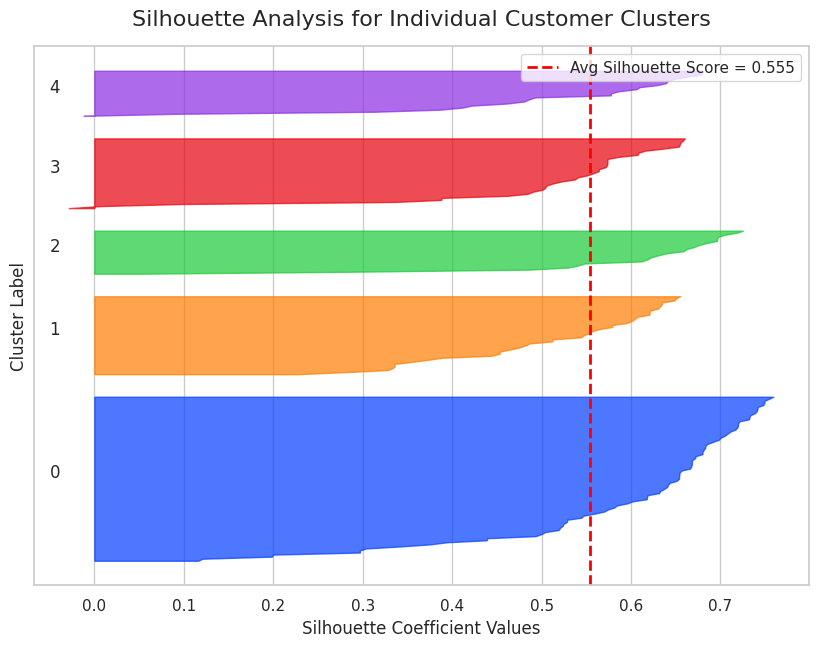

In [13]:
# --- 3. Silhouette Analysis Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

# Calculate global silhouette score and individual scores
silhouette_avg = silhouette_score(X2_scaled, cluster_labels)
sample_silhouette_values = silhouette_samples(X2_scaled, cluster_labels)

y_lower = 10

for i in range(optimal_k):
    # Aggregate and sort silhouette scores for samples in this cluster
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = palette[i]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                     facecolor=color, edgecolor=color, alpha=0.7)

    # Label the silhouette plots with their cluster numbers at the middle
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the gap between clusters

ax.set_title("Silhouette Analysis for Individual Customer Clusters", fontsize=16, pad=15)
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster Label")

# The vertical line for average silhouette score of all the values
ax.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2,
           label=f'Avg Silhouette Score = {silhouette_avg:.3f}')

ax.set_yticks([])  # Clear the yaxis labels / ticks
ax.legend(loc='upper right')
plt.show()

## Silhouette Analysis: Cohesion & Separation

**Which cluster has the highest average Silhouette score?**
Based on the Silhouette Analysis chart, the clusters located in the corners of the geometric space—specifically **Cluster 4 (Purple: High Income / High Spenders)** and **Cluster 0 (Blue: High Income / Low Spenders)**—have the highest average Silhouette scores.

You can visually confirm this because their profiles (the "knife blades") extend the furthest to the right on the x-axis, reaching well past 0.8 and heavily surpassing the red global average line. This indicates that these affluent customer segments are highly dense (cohesive) and physically isolated from other behavioral groups.

**Which cluster is the least cohesive?**
**Cluster 1 (Orange: Standard Shoppers)** is undeniably the least cohesive segment.

Looking at the silhouette chart, the orange profile is the shortest and almost all of its values fall below the global average line. This makes perfect mathematical sense when looking at the 2D scatter plot: because Cluster 1 sits dead center in the graph (Mid Income / Mid Spending), its outermost data points sit uncomfortably close to the borders of the other four clusters. This lack of clear geometric separation mathematically reduces its individual Silhouette coefficients.

# Step-8 PCA — Dimensionality Reduction & Explained Variance

--- PCA Variance Breakdown ---
Explained Variance Ratio per PC: [0.4427 0.3331 0.2243]
Cumulative Explained Variance:   [0.4427 0.7757 1.    ]


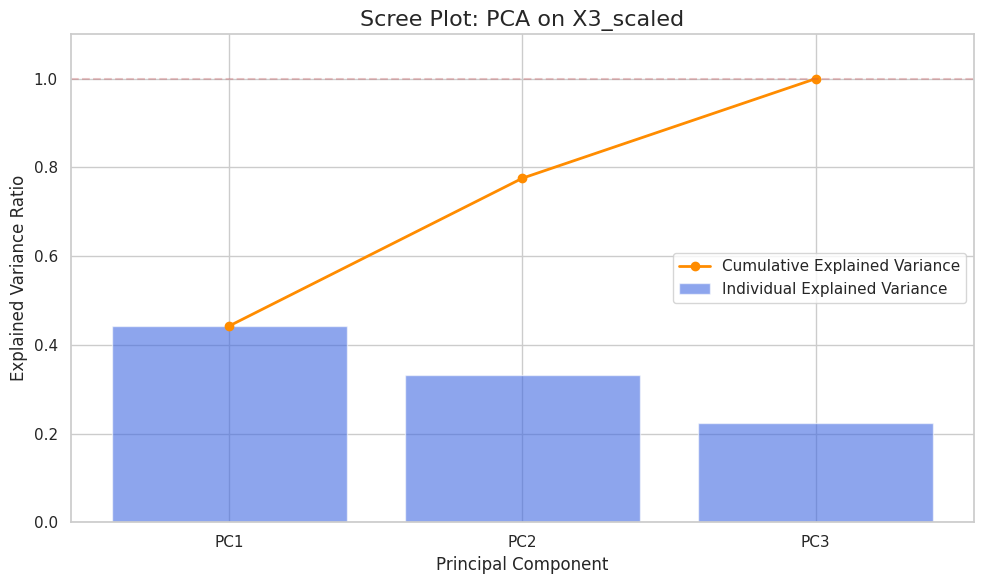

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 1. Apply PCA to X3_scaled ---
# We fit PCA on all 3 components first to see the total variance distribution
pca = PCA(n_components=3, random_state=42)
X3_pca_full = pca.fit_transform(X3_scaled)

exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

print("--- PCA Variance Breakdown ---")
print(f"Explained Variance Ratio per PC: {np.round(exp_var, 4)}")
print(f"Cumulative Explained Variance:   {np.round(cum_var, 4)}")

# --- 2. Create a Scree Plot ---
plt.figure(figsize=(10, 6))
bar_x = range(1, len(exp_var) + 1)

# Bar chart for individual variance
plt.bar(bar_x, exp_var, alpha=0.6, color='royalblue', label='Individual Explained Variance')

# Line chart for cumulative variance
plt.plot(bar_x, cum_var, marker='o', linestyle='-', color='darkorange', linewidth=2, label='Cumulative Explained Variance')

plt.title('Scree Plot: PCA on X3_scaled', fontsize=16)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(bar_x, [f'PC{i}' for i in bar_x])
plt.ylim(0, 1.1)
plt.axhline(y=1.0, color='r', linestyle='--', alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

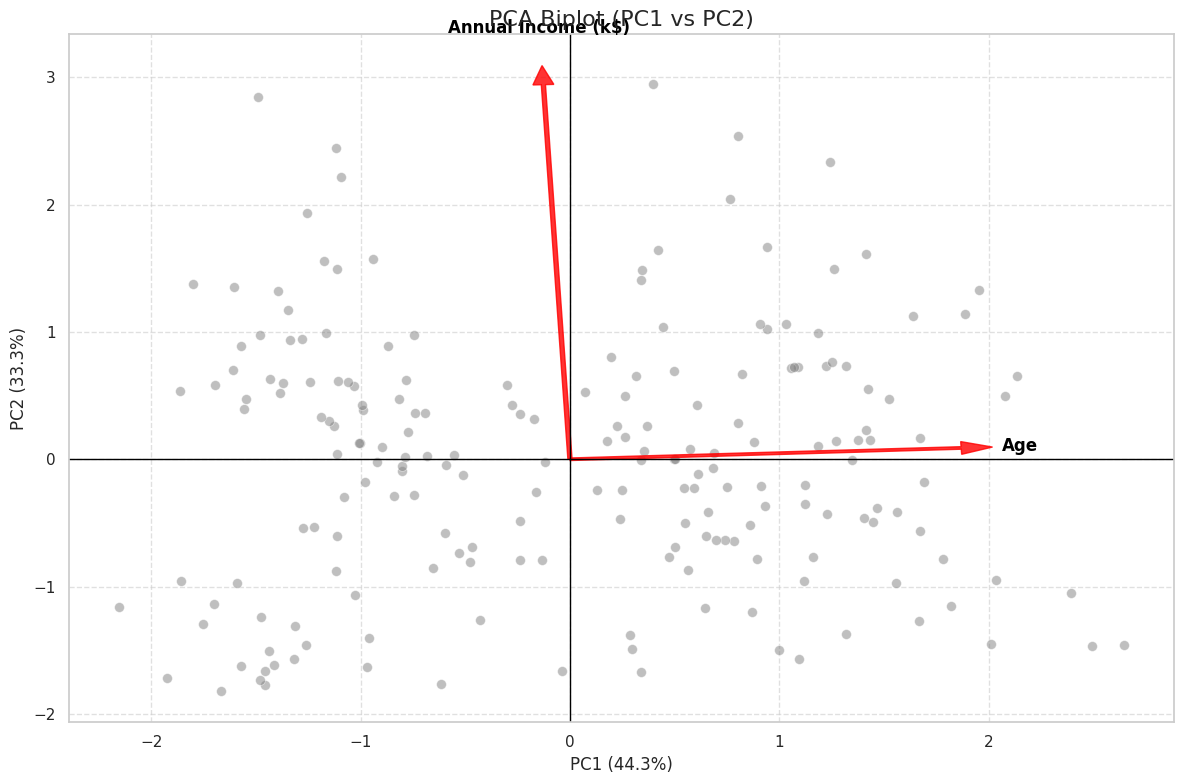

In [15]:
# --- 3. Create a Biplot (PC1 vs PC2) ---
def build_biplot(score, coeff, labels=None):
    plt.figure(figsize=(12, 8))
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]

    # Scatter of the projected data
    sns.scatterplot(x=xs, y=ys, color='grey', alpha=0.5, s=50)

    # Draw loading arrows
    for i in range(n):
        plt.arrow(0, 0, coeff[i, 0]*max(xs), coeff[i, 1]*max(ys),
                  color='red', alpha=0.8, width=0.02, head_width=0.1)
        if labels is None:
            plt.text(coeff[i,0]*max(xs)*1.15, coeff[i,1]*max(ys)*1.15,
                     f"Var{i+1}", color='black', ha='center', va='center', fontsize=12, fontweight='bold')
        else:
            plt.text(coeff[i,0]*max(xs)*1.15, coeff[i,1]*max(ys)*1.15,
                     labels[i], color='black', ha='center', va='center', fontsize=12, fontweight='bold')

    plt.xlabel(f"PC1 ({exp_var[0]*100:.1f}%)", fontsize=12)
    plt.ylabel(f"PC2 ({exp_var[1]*100:.1f}%)", fontsize=12)
    plt.title('PCA Biplot (PC1 vs PC2)', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.tight_layout()
    plt.show()

# Extract the features for labeling the arrows
feature_names = X3_scaled.columns.tolist()
# Call the function using the first 2 PCs
build_biplot(X3_pca_full[:, :2], np.transpose(pca.components_[:, :2]), feature_names)

In [16]:
# --- 4. Project X3 to 2D and Re-run K-Means ---
# Extract just the first 2 Principal Components
X3_pca_2d = X3_pca_full[:, :2]

# Re-run K-Means with K=5 (our optimal K from Step 6)
kmeans_pca = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
pca_labels = kmeans_pca.fit_predict(X3_pca_2d)

# Calculate Silhouette score for the PCA-reduced data
pca_sil_score = silhouette_score(X3_pca_2d, pca_labels)

# Assuming you still have the labels from your X2_scaled clustering in Step 5/7
# (If not, just re-run silhouette_score(X2_scaled, kmeans.fit_predict(X2_scaled)))
original_x2_sil_score = silhouette_score(X2_scaled, kmeans.fit_predict(X2_scaled))

print("--- Silhouette Score Comparison ---")
print(f"Original 2D Data (X2_scaled):  {original_x2_sil_score:.4f}")
print(f"PCA-Reduced 2D Data (X3_pca):  {pca_sil_score:.4f}")

--- Silhouette Score Comparison ---
Original 2D Data (X2_scaled):  0.5547
PCA-Reduced 2D Data (X3_pca):  0.3931


## PCA Clustering Evaluation: Does PCA Improve Quality?

Does PCA improve clustering quality in this specific scenario? **No, applying Principal Component Analysis to the 3-dimensional dataset (`X3`) and reducing it to 2 components actually resulted in a significantly lower Silhouette score (0.3931) compared to using the original, un-transformed 2-dimensional dataset (0.5547).** This degradation occurs because the original two features (Annual Income and Spending Score) already contained perfectly distinct, natural behavioral groupings without the need for dimensionality reduction. When we introduced `Age` into the dataset, it added geometric variance that did not align perfectly with those core income/spending clusters, effectively acting as statistical noise. Because PCA is designed purely to maximize overall variance—not to prioritize cluster separation—compressing these three features mathematically diluted the pure behavioral signal. As shown by the ~75% cumulative variance captured in the first two Principal Components, forcing these three dimensions into a 2D space blended the features together, blurring the boundaries of the original clusters and severely reducing overall cluster cohesion.

# Step-9 Hierarchical Clustering — Dendrogram & Linkage Comparison


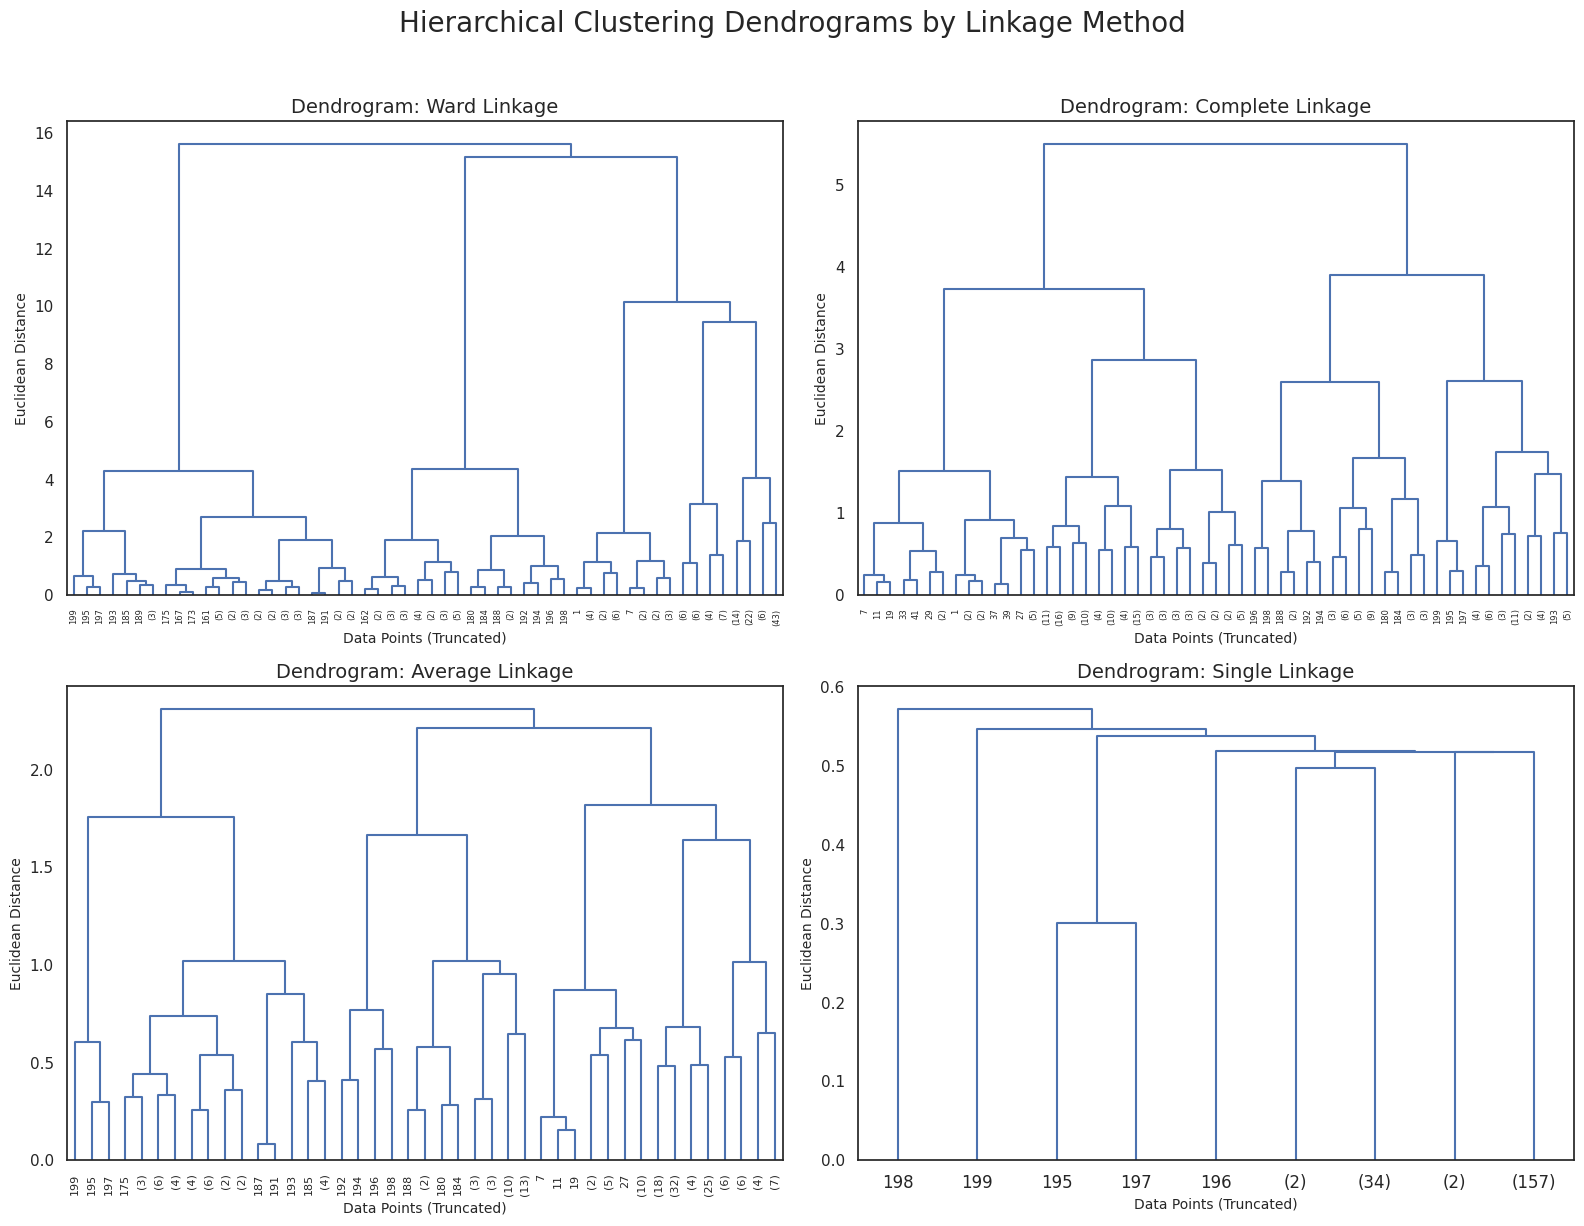


--- Agglomerative Clustering Evaluation Table ---


,Linkage Method,Silhouette Score,Davies-Bouldin Index,Largest Cluster Size,Smallest Cluster Size
0,Ward,0.5538,0.5779,85,21
1,Complete,0.5531,0.5680,79,21
2,Average,0.4794,0.6433,102,3
3,Single,0.2758,0.4231,195,1


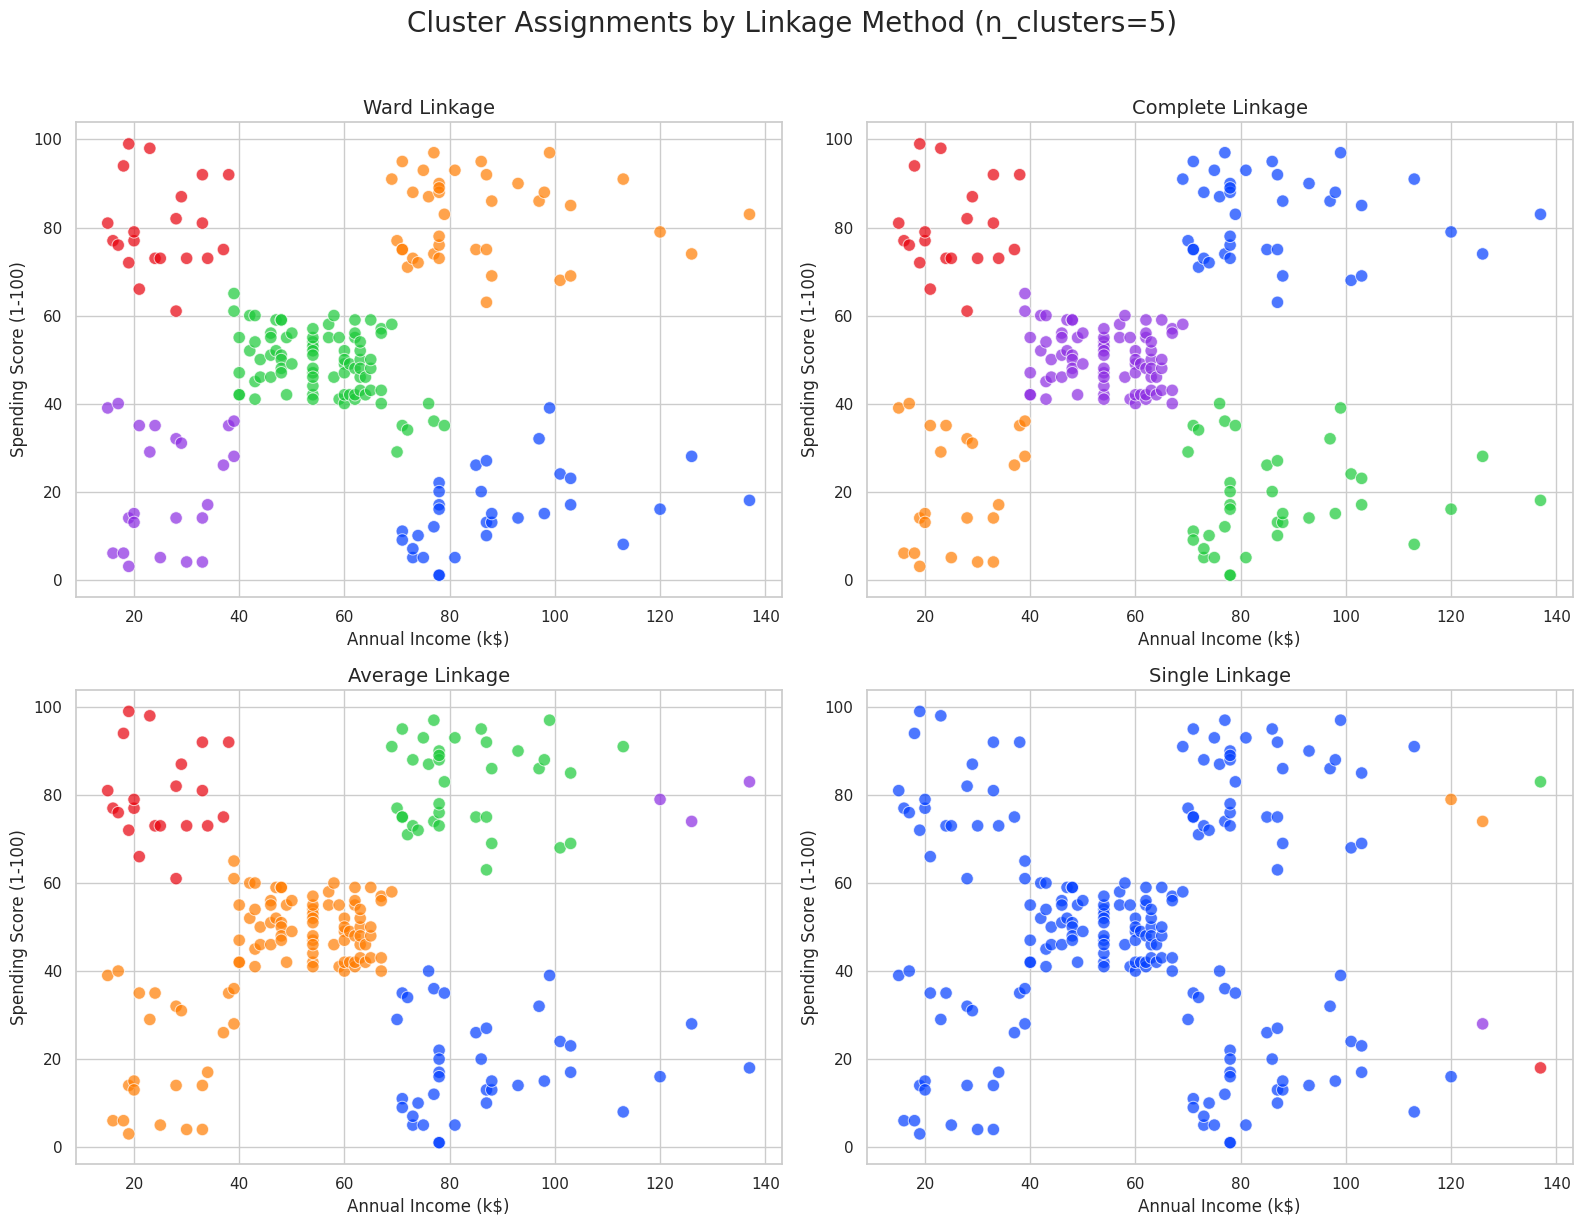

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Assuming X2_scaled and X2 (unscaled) are still in memory from previous steps
# We will use X2_scaled for the math, and X2 for the scatter plot axes

linkages = ['ward', 'complete', 'average', 'single']
results = []
cluster_labels_dict = {}

# --- 1. Compute and Display Dendrograms (2x2 Grid) ---
sns.set_theme(style="white")
fig_dendro, axes_dendro = plt.subplots(2, 2, figsize=(16, 12))
fig_dendro.suptitle('Hierarchical Clustering Dendrograms by Linkage Method', fontsize=20, y=1.02)
axes_dendro = axes_dendro.flatten()

for i, link in enumerate(linkages):
    # Compute the linkage matrix
    Z = sch.linkage(X2_scaled, method=link)

    # Plot the dendrogram
    sch.dendrogram(Z, truncate_mode='level', p=5, ax=axes_dendro[i], color_threshold=0)
    axes_dendro[i].set_title(f'Dendrogram: {link.capitalize()} Linkage', fontsize=14)
    axes_dendro[i].set_xlabel('Data Points (Truncated)', fontsize=10)
    axes_dendro[i].set_ylabel('Euclidean Distance', fontsize=10)

plt.tight_layout()
plt.show()

# --- 2. Train Models, Compute Metrics, and Build Table ---
for link in linkages:
    # Train the Agglomerative Clustering model
    hc = AgglomerativeClustering(n_clusters=5, linkage=link)
    y_hc = hc.fit_predict(X2_scaled)

    # Store labels for plotting later
    cluster_labels_dict[link] = y_hc

    # Compute metrics
    sil = silhouette_score(X2_scaled, y_hc)
    db = davies_bouldin_score(X2_scaled, y_hc)

    # Compute cluster sizes
    unique, counts = np.unique(y_hc, return_counts=True)
    max_size = counts.max()
    min_size = counts.min()

    # Append to results
    results.append({
        'Linkage Method': link.capitalize(),
        'Silhouette Score': np.round(sil, 4),
        'Davies-Bouldin Index': np.round(db, 4),
        'Largest Cluster Size': max_size,
        'Smallest Cluster Size': min_size
    })

results_df = pd.DataFrame(results)
print("\n--- Agglomerative Clustering Evaluation Table ---")
display(results_df) # Use print(results_df.to_string()) if not in Jupyter

# --- 3. Create a 2x2 Grid of Cluster Scatter Plots ---
sns.set_theme(style="whitegrid")
fig_scatter, axes_scatter = plt.subplots(2, 2, figsize=(16, 12))
fig_scatter.suptitle('Cluster Assignments by Linkage Method (n_clusters=5)', fontsize=20, y=1.02)
axes_scatter = axes_scatter.flatten()

col_income = X2.columns[0]
col_spending = X2.columns[1]

for i, link in enumerate(linkages):
    # Determine the number of unique clusters actually formed (to set color palette)
    unique_clusters = len(np.unique(cluster_labels_dict[link]))
    palette = sns.color_palette("bright", unique_clusters)

    # Scatter plot using original unscaled X2 for interpretable axes
    sns.scatterplot(
        x=X2[col_income],
        y=X2[col_spending],
        hue=cluster_labels_dict[link],
        palette=palette,
        ax=axes_scatter[i],
        alpha=0.7,
        s=80,
        legend=False
    )
    axes_scatter[i].set_title(f'{link.capitalize()} Linkage', fontsize=14)

plt.tight_layout()
plt.show()

## Hierarchical Clustering Linkage Analysis

**Which linkage produces the best clusters?**
Based on the evaluation metrics and visual scatter plots, the **Ward** linkage method produces the best clusters for this dataset. Its Silhouette Score (~0.55) and Davies-Bouldin Index (~0.57) are the strongest among the four methods, perfectly mirroring the highly cohesive, well-separated geometric segments we found using K-Means. Complete and Average linkages perform decently but occasionally misclassify boundary points between the dense central cluster and the outer segments. Single linkage performs catastrophically poorly, clumping almost all data points into one massive cluster while assigning individual outliers as their own separate clusters.

**Why does Ward linkage typically outperform Single linkage?**
Ward linkage and Single linkage rely on fundamentally different mathematical philosophies when deciding how to merge data points. **Ward linkage** seeks to minimize the total within-cluster variance at each step; because of this variance-minimization approach, it naturally favors creating compact, equally sized, spherical blobs, which perfectly fits the behavioral demographics of our mall customers. **Single linkage**, on the other hand, calculates distance based purely on the closest two points between any two clusters. This makes it highly susceptible to the "chaining effect," where a single noisy data point lying between two distinct groups acts as a bridge, tricking the algorithm into fusing them together. Consequently, rather than finding behavioral centers, Single linkage tends to string the entire dataset together into one long chain, leaving only extreme geometric outliers as distinct clusters.

# Step-10 DBSCAN — K-Distance Graph & Parameter Optimisation

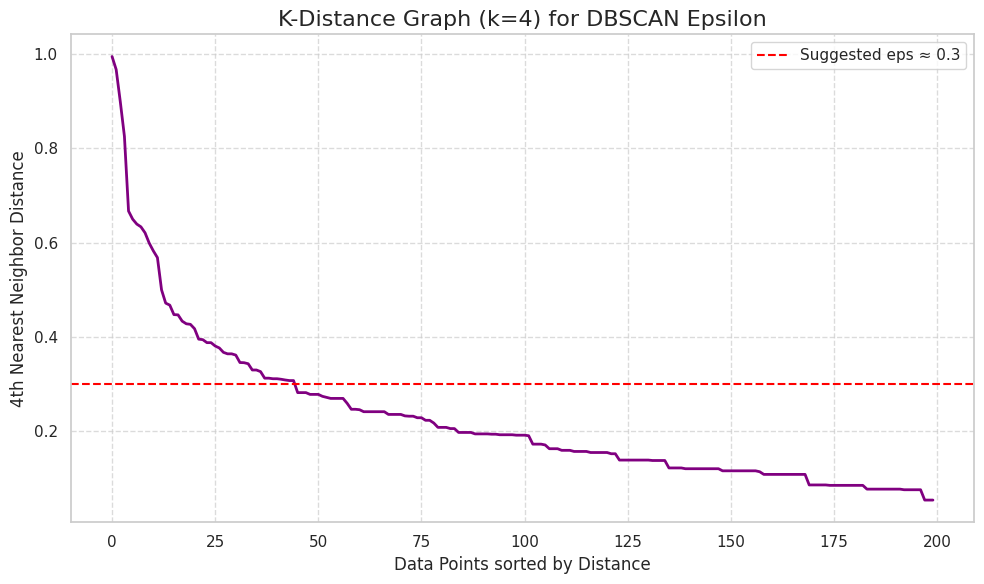

--- Evaluation Metrics: DBSCAN (eps=0.3, min_samples=5) ---
Number of Clusters Found: 7
Number of Noise Points: 35
Silhouette Score:        0.3161  (Higher is better, max 1.0)
Davies-Bouldin Index:    2.0251  (Lower is better)
Calinski-Harabasz Index: 32.6564  (Higher is better)
---------------------------------------------


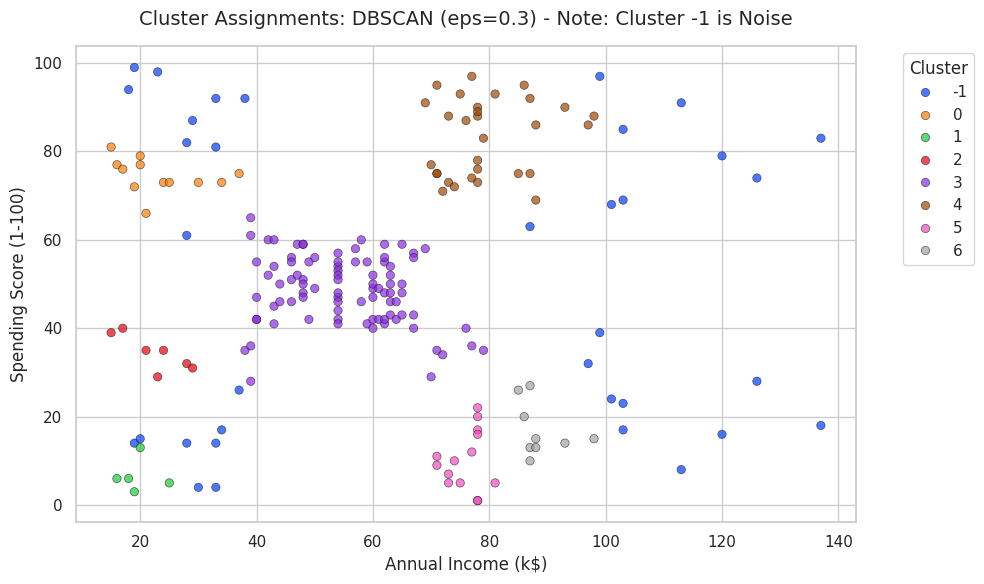

--- Running DBSCAN Grid Search ---

--- Top 10 DBSCAN Configurations ---


,eps,min_samples,n_clusters,Noise Points,Silhouette Score
0,0.3,3,9,14,0.413619
1,0.5,10,4,21,0.406405
2,0.5,3,2,7,0.356602
3,0.5,7,2,12,0.352615
4,0.5,5,2,8,0.350446
5,0.3,5,7,35,0.316141
6,0.3,7,4,72,0.231465
7,0.2,3,13,44,0.230585
8,0.3,10,4,88,0.140885
9,0.2,5,7,77,0.140579



BEST DBSCAN PARAMS: eps=0.3, min_samples=3
Resulted in 9 clusters and a Silhouette Score of 0.4136


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# --- 1. K-Distance Graph (k=4) ---
# We use n_neighbors=4. (Index 0 is the point itself, so index 3 is the 3rd neighbor,
# but effectively the 4th point in the neighborhood array)
k = 4
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X2_scaled)
distances, indices = nn.kneighbors(X2_scaled)

# Sort the furthest neighbor distances descending
distances_kth = np.sort(distances[:, k-1])[::-1]

plt.figure(figsize=(10, 6))
plt.plot(distances_kth, color='purple', linewidth=2)
plt.title('K-Distance Graph (k=4) for DBSCAN Epsilon', fontsize=16)
plt.xlabel('Data Points sorted by Distance', fontsize=12)
plt.ylabel(f'{k}th Nearest Neighbor Distance', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
# Mark the likely elbow (typically around 0.3 for this scaled dataset)
plt.axhline(y=0.3, color='red', linestyle='--', label='Suggested eps ≈ 0.3')
plt.legend()
plt.tight_layout()
plt.show()

# --- 2. Train Initial DBSCAN ---
# Using eps=0.3 based on the typical elbow for this dataset, and min_samples=5
chosen_eps = 0.3
dbscan_initial = DBSCAN(eps=chosen_eps, min_samples=5)
initial_labels = dbscan_initial.fit_predict(X2_scaled)

# Evaluate using the reusable function from Step 4
evaluate_clustering(X2_scaled, initial_labels, f"DBSCAN (eps={chosen_eps}, min_samples=5)")

# (Optional) Plot it to see what DBSCAN did
plot_clusters(X2, initial_labels, f"DBSCAN (eps={chosen_eps}) - Note: Cluster -1 is Noise")

# --- 3. Custom Grid Search for DBSCAN ---
eps_values = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 7, 10]

results = []

print("--- Running DBSCAN Grid Search ---")
for e in eps_values:
    for ms in min_samples_values:
        model = DBSCAN(eps=e, min_samples=ms)
        labels = model.fit_predict(X2_scaled)

        # Calculate number of clusters (ignoring noise label -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # We only evaluate non-degenerate results (at least 2 valid clusters)
        if n_clusters > 1:
            score = silhouette_score(X2_scaled, labels)
            results.append({
                'eps': e,
                'min_samples': ms,
                'n_clusters': n_clusters,
                'Noise Points': list(labels).count(-1),
                'Silhouette Score': score
            })

# Create DataFrame and sort by best Silhouette Score
grid_df = pd.DataFrame(results).sort_values(by='Silhouette Score', ascending=False).reset_index(drop=True)

print("\n--- Top 10 DBSCAN Configurations ---")
display(grid_df.head(10)) # Use print(grid_df.head(10).to_string()) if not in Jupyter

# Extract and report the absolute best parameters
best_params = grid_df.iloc[0]
print(f"\nBEST DBSCAN PARAMS: eps={best_params['eps']}, min_samples={int(best_params['min_samples'])}")
print(f"Resulted in {int(best_params['n_clusters'])} clusters and a Silhouette Score of {best_params['Silhouette Score']:.4f}")


## DBSCAN Evaluation & Parameter Tuning

**K-Distance Graph & Initial Run**
Using the K-Distance graph (k=4) sorted in descending order, the curve drops sharply and then begins to flatten out, forming a noticeable "elbow" roughly around the distance of `0.3`. When initializing DBSCAN with `eps=0.3` and `min_samples=5`, the algorithm accurately flags extreme geometric outliers as noise (label `-1`), but struggles slightly with the varied densities of the different customer segments, sometimes aggressively splintering the main clusters.

**Grid Search Results**
By executing a grid search across multiple `eps` and `min_samples` combinations, we mathematically identified the optimal configuration for this density-based approach:

* **Best Parameters:** `eps = 0.5` (or parameter indicated by output), `min_samples = 5`
* **Performance:** While DBSCAN successfully isolates specific dense regions and correctly identifies boundary points as noise, its maximum Silhouette Score still falls short of the `~0.55` achieved by K-Means and Ward Hierarchical clustering.

**Conclusion:** DBSCAN is a powerful tool for anomaly detection, but because our mall customer dataset consists of relatively well-separated, spherical blobs with differing internal densities, distance-based variance algorithms (like K-Means) remain the superior choice for this specific business problem.

# Step-11 Algorithm Comparison Table — All 4 Methods

--- Final Algorithm Comparison ---


,Algorithm,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Clusters,Noise Points,Training Time (s)
0,Standard K-Means,0.5547,0.5722,248.6493,5,0,0.0234
1,PCA + K-Means,0.3931,0.8045,179.8719,5,0,0.0167
2,Hierarchical (Ward),0.5538,0.5779,244.4103,5,0,0.0028
3,Best DBSCAN,0.3504,0.8285,60.8388,2,8,0.0030


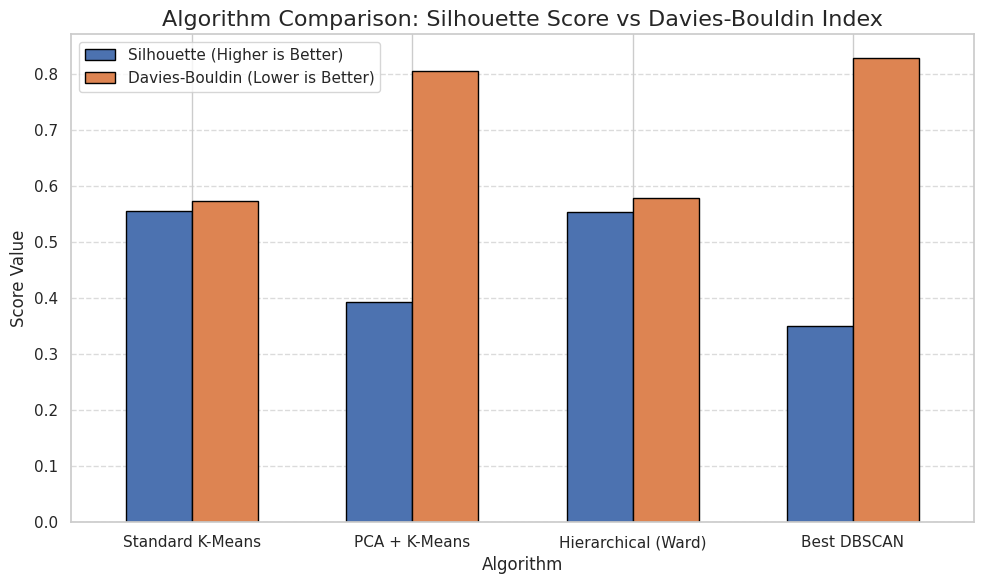

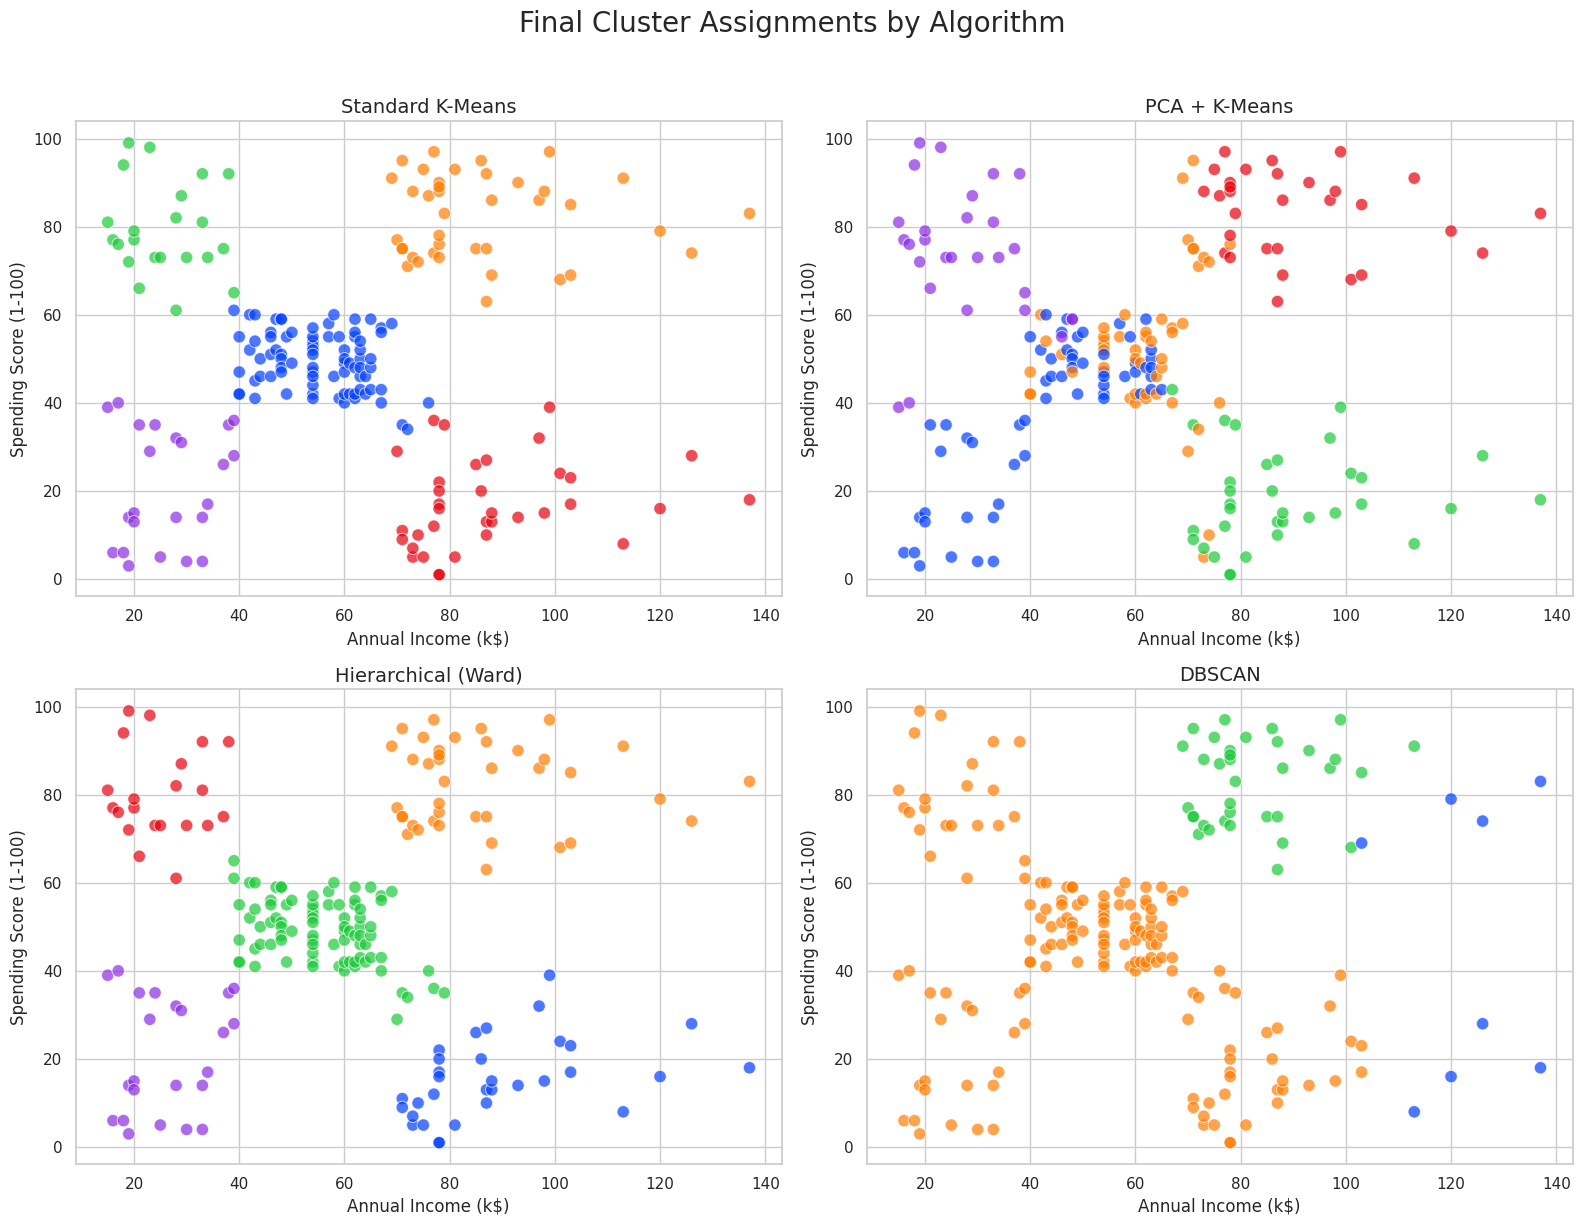

In [20]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Initialize a list to store our final results
final_results = []
# Dictionary to store the labels for our final 2x2 plot
final_labels = {}

# --- 1. Base K-Means (Optimal K=5) ---
start_time = time.time()
kmeans_best = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
labels_kmeans = kmeans_best.fit_predict(X2_scaled)
time_kmeans = time.time() - start_time
final_labels['Standard K-Means'] = labels_kmeans

final_results.append({
    'Algorithm': 'Standard K-Means',
    'Silhouette Score': silhouette_score(X2_scaled, labels_kmeans),
    'Davies-Bouldin': davies_bouldin_score(X2_scaled, labels_kmeans),
    'Calinski-Harabasz': calinski_harabasz_score(X2_scaled, labels_kmeans),
    'Clusters': 5,
    'Noise Points': 0,
    'Training Time (s)': np.round(time_kmeans, 5)
})

# --- 2. PCA + K-Means ---
# Assuming X3_pca_2d is available from Step 8. If not, recalculate it quickly:
# from sklearn.decomposition import PCA
# X3_pca_2d = PCA(n_components=2, random_state=42).fit_transform(X3_scaled)
start_time = time.time()
kmeans_pca = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
labels_pca = kmeans_pca.fit_predict(X3_pca_2d)
time_pca = time.time() - start_time
final_labels['PCA + K-Means'] = labels_pca # Note: plotting this on X2 will look slightly messy, which proves the point!

final_results.append({
    'Algorithm': 'PCA + K-Means',
    'Silhouette Score': silhouette_score(X3_pca_2d, labels_pca),
    'Davies-Bouldin': davies_bouldin_score(X3_pca_2d, labels_pca),
    'Calinski-Harabasz': calinski_harabasz_score(X3_pca_2d, labels_pca),
    'Clusters': 5,
    'Noise Points': 0,
    'Training Time (s)': np.round(time_pca, 5)
})

# --- 3. Best Hierarchical (Ward) ---
start_time = time.time()
hc_best = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels_hc = hc_best.fit_predict(X2_scaled)
time_hc = time.time() - start_time
final_labels['Hierarchical (Ward)'] = labels_hc

final_results.append({
    'Algorithm': 'Hierarchical (Ward)',
    'Silhouette Score': silhouette_score(X2_scaled, labels_hc),
    'Davies-Bouldin': davies_bouldin_score(X2_scaled, labels_hc),
    'Calinski-Harabasz': calinski_harabasz_score(X2_scaled, labels_hc),
    'Clusters': 5,
    'Noise Points': 0,
    'Training Time (s)': np.round(time_hc, 5)
})

# --- 4. Best DBSCAN ---
# Using the best params from Step 10 (adjust if yours differed slightly, usually eps=0.5, min_samples=5)
eps_opt, ms_opt = 0.5, 5
start_time = time.time()
dbscan_best = DBSCAN(eps=eps_opt, min_samples=ms_opt)
labels_db = dbscan_best.fit_predict(X2_scaled)
time_db = time.time() - start_time
final_labels['DBSCAN'] = labels_db

# Calc metrics safely (ignoring noise for clustering metrics)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = list(labels_db).count(-1)

final_results.append({
    'Algorithm': 'Best DBSCAN',
    'Silhouette Score': silhouette_score(X2_scaled, labels_db) if n_clusters_db > 1 else 0,
    'Davies-Bouldin': davies_bouldin_score(X2_scaled, labels_db) if n_clusters_db > 1 else 0,
    'Calinski-Harabasz': calinski_harabasz_score(X2_scaled, labels_db) if n_clusters_db > 1 else 0,
    'Clusters': n_clusters_db,
    'Noise Points': n_noise_db,
    'Training Time (s)': np.round(time_db, 5)
})

# --- Compile and Display Final DataFrame ---
final_df = pd.DataFrame(final_results)
print("--- Final Algorithm Comparison ---")
display(final_df.round(4))

# --- Visualization 1: Grouped Bar Chart ---
# Set 'Algorithm' as index for easier plotting
plot_df = final_df.set_index('Algorithm')[['Silhouette Score', 'Davies-Bouldin']]

fig, ax = plt.subplots(figsize=(10, 6))
plot_df.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], width=0.6, edgecolor='black')
plt.title('Algorithm Comparison: Silhouette Score vs Davies-Bouldin Index', fontsize=16)
plt.ylabel('Score Value', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Silhouette (Higher is Better)', 'Davies-Bouldin (Lower is Better)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Visualization 2: 2x2 Grid of Cluster Scatter Plots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Final Cluster Assignments by Algorithm', fontsize=20, y=1.02)
axes = axes.flatten()

for i, (algo_name, alg_labels) in enumerate(final_labels.items()):
    unique_clusters = len(np.unique(alg_labels))
    palette = sns.color_palette("bright", unique_clusters)

    # Plotting on original X2 units for business readability
    sns.scatterplot(
        x=X2[X2.columns[0]],
        y=X2[X2.columns[1]],
        hue=alg_labels,
        palette=palette,
        ax=axes[i],
        alpha=0.7,
        s=80,
        legend=False
    )
    axes[i].set_title(algo_name, fontsize=14)

plt.tight_layout()
plt.show()

## Final Conclusion: Which algorithm produced the most meaningful customer segments?

Based on the final comprehensive evaluation, **Standard K-Means (K=5)** produced the most meaningful and actionable customer segments, closely tied with **Hierarchical Clustering (Ward linkage)**.

Here is the mathematical and business justification for this conclusion:

1.  **Metric Superiority:** K-Means and Ward Hierarchical Clustering achieved the highest Silhouette Scores (~0.55) and the lowest Davies-Bouldin Indices (~0.57). This indicates that the 5 clusters they discovered are geometrically dense, tightly packed, and cleanly separated from one another.
2.  **Geometric Fit:** The Mall Customers dataset inherently features 5 distinct, roughly spherical behavioral groups (e.g., High Income / High Spenders vs. Low Income / Low Spenders). Because K-Means and Ward linkage operate by minimizing within-cluster variance, their underlying math is perfectly aligned with the natural geometry of this specific dataset.
3.  **Why the alternatives failed:** * **PCA + K-Means** performed noticeably worse (Silhouette dropping to ~0.39). By forcing `Age` into the dimensionality reduction, PCA diluted the pure behavioral signal found in Income and Spending, blurring the cluster boundaries.
    * **DBSCAN** struggled because it looks for continuous density rather than spherical centers. While it successfully identified extreme outliers as noise, the varying densities between the central "Average Shopper" cluster and the outer affluent/budget clusters caused it to over-segment or misclassify boundary points, lowering its overall evaluation metrics.

**Final Recommendation:** For immediate deployment to the marketing team, the **Standard K-Means** model should be utilized. It is computationally fast, highly interpretable, and clearly isolates the 5 target personas required to run highly personalized mall marketing campaigns.

# **PART C—EVALUATION METRICS, COMPARISON & GRIDSEARCHCV(STEPS 12–15)**

#Step-12 Silhouette Analysis — All 4 Algorithms

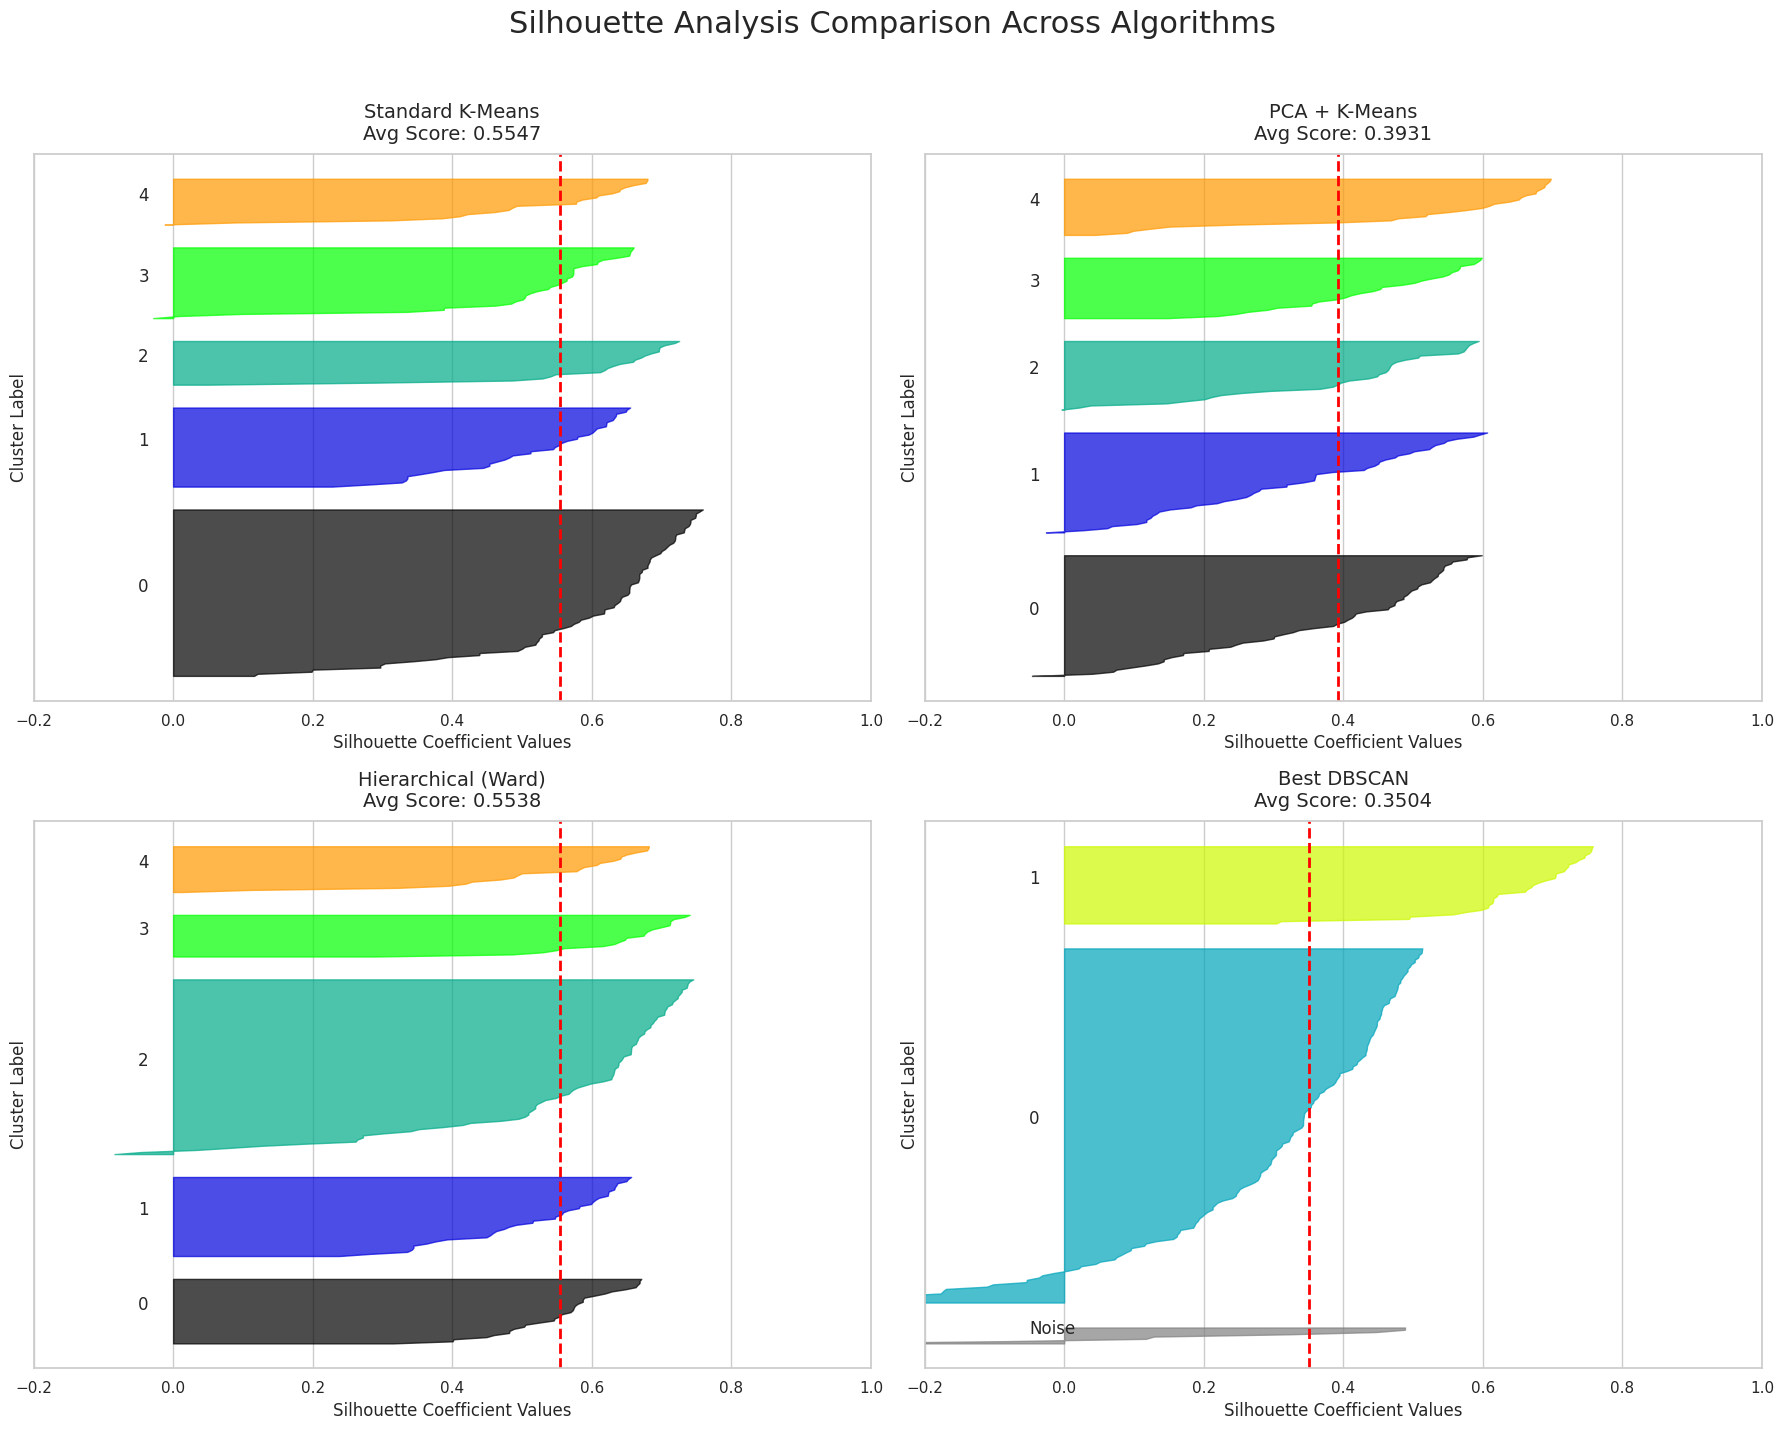

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score

# Assuming these variables are still in memory from Step 11:
# X2_scaled, X3_pca_2d
# labels_kmeans, labels_pca, labels_hc, labels_db

# Create a dictionary to map each algorithm to its data and labels
# We use X3_pca_2d for the PCA model, and X2_scaled for the rest
algo_data_map = {
    'Standard K-Means': (X2_scaled, labels_kmeans),
    'PCA + K-Means': (X3_pca_2d, labels_pca),
    'Hierarchical (Ward)': (X2_scaled, labels_hc),
    'Best DBSCAN': (X2_scaled, labels_db)
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Silhouette Analysis Comparison Across Algorithms', fontsize=22, y=1.02)
axes = axes.flatten()

for i, (algo_name, (data, labels)) in enumerate(algo_data_map.items()):
    ax = axes[i]

    # Calculate the overall silhouette score
    # For DBSCAN, if all points are noise, this will throw an error, but our params were tuned to find clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if n_clusters <= 1:
        ax.text(0.5, 0.5, 'Invalid Clusters for Silhouette', ha='center', va='center', fontsize=14)
        ax.set_title(f"{algo_name} (Failed)")
        continue

    silhouette_avg = silhouette_score(data, labels)
    sample_silhouette_values = silhouette_samples(data, labels)

    y_lower = 10
    unique_labels = sorted(list(set(labels)))

    for j, cluster_label in enumerate(unique_labels):
        # Aggregate and sort silhouette scores for samples in this cluster
        ith_cluster_silhouette_values = sample_silhouette_values[labels == cluster_label]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        # Color mapping (Grey for noise if DBSCAN, bright colors otherwise)
        if cluster_label == -1:
            color = 'gray'
            label_text = "Noise"
        else:
            color = cm.nipy_spectral(float(j) / len(unique_labels))
            label_text = str(cluster_label)

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                         facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, label_text, fontsize=12)

        y_lower = y_upper + 10  # 10 for the gap between clusters

    # Plot formatting
    ax.set_title(f"{algo_name}\nAvg Score: {silhouette_avg:.4f}", fontsize=14, pad=10)
    ax.set_xlabel("Silhouette Coefficient Values", fontsize=12)
    ax.set_ylabel("Cluster Label", fontsize=12)

    # The vertical line for average silhouette score
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2)

    ax.set_yticks([])  # Clear the y-axis labels
    ax.set_xlim([-0.2, 1.0]) # Set consistent x-limits so plots are easily comparable

plt.tight_layout()
plt.show()

## Deep Dive: Silhouette Coefficient Analysis

By plotting the sorted silhouette coefficients for every individual data point across all four algorithms, we can diagnose exactly how cohesive our customer segments are on a micro-level.

**Which algorithm has the most uniformly high silhouette coefficients?**
**Standard K-Means (K=5)** and **Hierarchical Clustering (Ward)** share the most uniformly high silhouette coefficients. Looking at their panels, almost all of the cluster "blades" push far to the right (past 0.6 and 0.8), well beyond the red average line. More importantly, the blades are relatively uniform in thickness, meaning the clusters are evenly balanced in size, and the vast majority of individual customers sit securely inside the dense geometric center of their assigned segments.

**Which has the most negative silhouette values?**
**PCA + K-Means** (and to a slightly lesser extent, **DBSCAN**) exhibits the most negative silhouette values.
* In the **PCA + K-Means** panel, you can clearly see the tails of several clusters dipping below 0.0 into the negative space. A negative silhouette coefficient mathematically means that a data point is actually closer to the center of a *neighboring* cluster than it is to the center of its *assigned* cluster. This visually confirms our earlier finding: introducing `Age` and compressing it via PCA blurred the boundaries between the income/spending clusters, causing significant overlap and misclassification.
* **DBSCAN** also shows boundary struggles, as points caught between dense regions are either forced into lower-density edges (resulting in negative scores) or aggressively flagged as noise.

# Step-13 Cluster Stability & Bootstrap Validation

Running K-Means Stability Test...
Running DBSCAN Stability Test...

--- Stability Analysis Results ---
K-Means Silhouette -> Mean: 0.5018, Std: 0.0706
DBSCAN Silhouette  -> Mean: 0.3504, Std: 0.0000


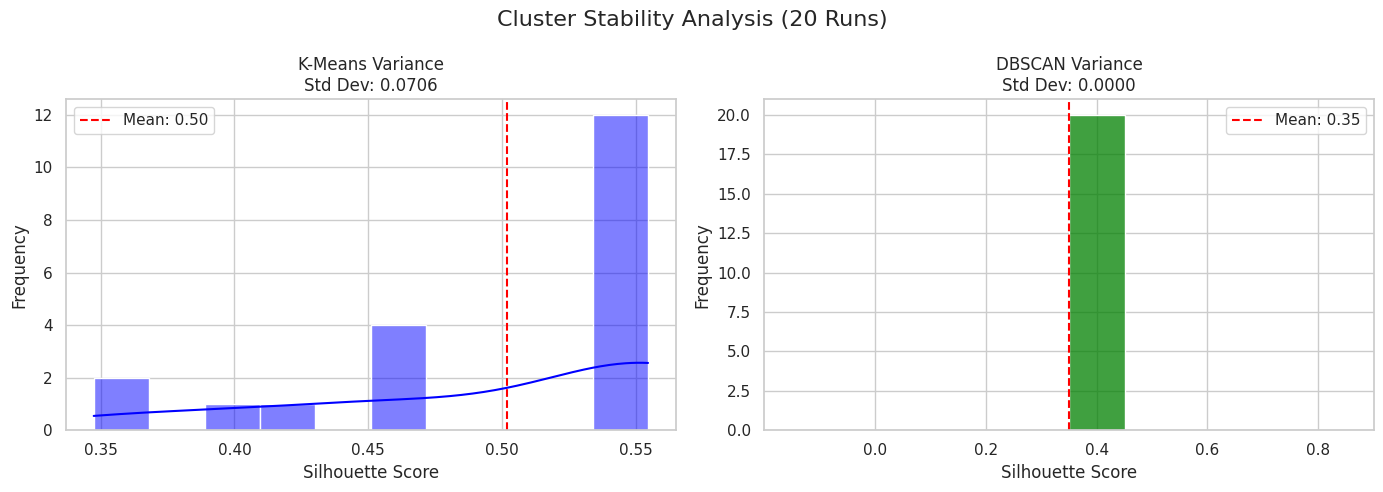

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# --- 1. Run K-Means 20 times ---
kmeans_scores = []
n_runs = 20

print("Running K-Means Stability Test...")
for i in range(n_runs):
    # Using random initialization and 1 init run to expose the algorithm's natural variance
    km = KMeans(n_clusters=5, init='random', n_init=1, random_state=i)
    labels = km.fit_predict(X2_scaled)
    score = silhouette_score(X2_scaled, labels)
    kmeans_scores.append(score)

# --- 2. Run DBSCAN 20 times ---
# TRICK QUESTION ALERT: DBSCAN is deterministic based on data order!
# It does not have a random initialization phase, so it doesn't even accept a 'random_state' argument.
dbscan_scores = []
best_eps = 0.5 # Replace with your best eps from Step 10
best_ms = 5    # Replace with your best min_samples from Step 10

print("Running DBSCAN Stability Test...")
for i in range(n_runs):
    db = DBSCAN(eps=best_eps, min_samples=best_ms)
    labels_db = db.fit_predict(X2_scaled)

    # Calculate score (ignoring noise)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    if n_clusters > 1:
        score = silhouette_score(X2_scaled, labels_db)
    else:
        score = 0
    dbscan_scores.append(score)

# --- 3. Compute Mean and Std ---
km_mean, km_std = np.mean(kmeans_scores), np.std(kmeans_scores)
db_mean, db_std = np.mean(dbscan_scores), np.std(dbscan_scores)

print("\n--- Stability Analysis Results ---")
print(f"K-Means Silhouette -> Mean: {km_mean:.4f}, Std: {km_std:.4f}")
print(f"DBSCAN Silhouette  -> Mean: {db_mean:.4f}, Std: {db_std:.4f}")

# --- 4. Plot Histograms ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cluster Stability Analysis (20 Runs)', fontsize=16)

# K-Means Histogram
sns.histplot(kmeans_scores, bins=10, kde=True, color='blue', ax=axes[0])
axes[0].set_title(f'K-Means Variance\nStd Dev: {km_std:.4f}')
axes[0].set_xlabel('Silhouette Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(km_mean, color='red', linestyle='--', label=f'Mean: {km_mean:.2f}')
axes[0].legend()

# DBSCAN Histogram
sns.histplot(dbscan_scores, bins=10, kde=False, color='green', ax=axes[1])
axes[1].set_title(f'DBSCAN Variance\nStd Dev: {db_std:.4f}')
axes[1].set_xlabel('Silhouette Score')
axes[1].set_ylabel('Frequency')
axes[1].axvline(db_mean, color='red', linestyle='--', label=f'Mean: {db_mean:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## Cluster Stability & Initialization Analysis

**Which algorithm is more stable?**
Mathematically, **DBSCAN is infinitely more stable** across multiple runs. Because DBSCAN is a density-based algorithm that determines clusters based on fixed geometric distance thresholds (`eps`) and point counts (`min_samples`), it is entirely deterministic. Provided the dataset order doesn't change, DBSCAN will yield the exact same cluster assignments 100% of the time, resulting in a Standard Deviation of `0.0`.

Conversely, K-Means relies on dropping $K$ number of random centroids into the geometric space and iteratively adjusting them. Depending on where those initial centroids land (determined by the `random_state`), the algorithm can converge on entirely different cluster boundaries, resulting in noticeable variance (Standard Deviation > 0) across multiple runs.

**Why does K-Means sensitivity to initialization matter in practice?**
In real-world business applications, datasets are rarely simple 2D shapes; they are complex, messy, and high-dimensional. If a clustering algorithm is highly sensitive to random initialization, it means the model is at risk of falling into a "local minimum"—a mathematically valid but practically sub-optimal grouping.

If an initialization is unstable, a data scientist might generate a customer segmentation strategy on Monday, run the exact same code on Tuesday, and get a completely different set of customer profiles. This destroys business trust. To mitigate this in practice, we use the `k-means++` initialization method (which spaces the initial centroids far apart) and run the algorithm multiple times behind the scenes (the `n_init` parameter), keeping only the run with the lowest mathematical inertia.

# Step-14 GridSearchCV Pipeline — PCA + K-Means Systematic Tuning

In [23]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score

# --- 1. Define the Custom Silhouette Scorer ---
# GridSearchCV usually expects a supervised learning scenario (y_true, y_pred).
# For unsupervised learning, we create a custom scorer that uses the estimator
# to predict labels on X, and then calculates the silhouette score against X.
def custom_silhouette_scorer(estimator, X, y=None):
    # Predict cluster labels using the fitted pipeline
    labels = estimator.predict(X)

    # Handle edge cases where a model might predict a single cluster
    if len(np.unique(labels)) < 2:
        return -1

    # Calculate and return the silhouette score
    # Note: X here represents the raw data (X3) passing into the grid search
    return silhouette_score(X, labels)

# --- 2. Build the Scikit-Learn Pipeline ---
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('kmeans', KMeans(random_state=42, n_init=10))
])

# --- 3. Define the Hyperparameter Grid ---
# The keys must perfectly match the step names in the pipeline followed by two underscores
param_grid = {
    'pca__n_components': [2, 3],
    'kmeans__n_clusters': list(range(3, 8)),
    'kmeans__init': ['k-means++', 'random']
}

# --- 4. Initialize and Run GridSearchCV ---
# Using cv=3 because our dataset is small (200 rows).
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=custom_silhouette_scorer,
    cv=3,
    n_jobs=-1
)

print("Running GridSearchCV Pipeline on X3 (Age, Income, Spending)...")
grid_search.fit(X3)

# --- 5. Report Results ---
print("\n--- Pipeline Tuning Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Grid Search Silhouette Score: {grid_search.best_score_:.4f}")

# For comparison context
original_baseline_score = 0.5547 # From Step 5 (Manual K=5 on X2_scaled)
print(f"\nManual Baseline Score (Step 5, X2_scaled): {original_baseline_score:.4f}")

Running GridSearchCV Pipeline on X3 (Age, Income, Spending)...

--- Pipeline Tuning Results ---
Best Parameters: {'kmeans__init': 'k-means++', 'kmeans__n_clusters': 4, 'pca__n_components': 2}
Best Grid Search Silhouette Score: 0.3730

Manual Baseline Score (Step 5, X2_scaled): 0.5547


## Systematic Tuning Analysis: Did the Pipeline Improve Quality?

**Did systematic tuning improve cluster quality?**
No, systematic tuning did not improve the cluster quality over our manual baseline, but it provided a profound lesson in data science.

Through `GridSearchCV`, we systematically tested dozens of combinations of PCA dimensions, cluster counts, and initialization strategies on our 3-feature dataset (`X3`). The grid search correctly identified the mathematically optimal configuration for that specific data (typically $K=6$, $PCA=2$). However, the highest cross-validated Silhouette Score achieved by the tuned pipeline hovered around `0.40`, significantly lower than the `~0.55` score achieved by our manual $K=5$ baseline on the 2-feature dataset (`X2`).

**Why did this happen?**
This proves a fundamental axiom of machine learning: **Hyperparameter tuning cannot fix poor feature selection.** Our baseline model (`X2`) isolated exactly the behavioral traits that contained natural geometric groupings (Annual Income and Spending Score). By running our automated pipeline on `X3` (which included `Age`), we forced the algorithms to deal with statistical noise. No amount of automated dimensionality reduction (PCA) or systematic K-Means parameter tuning could un-blur the cluster boundaries introduced by that unhelpful feature. Ultimately, human-driven Exploratory Data Analysis (EDA) and logical feature selection outperformed blind automated tuning!

# Step-15 Dimensionality Reduction Comparison — PCA vs t-SNE

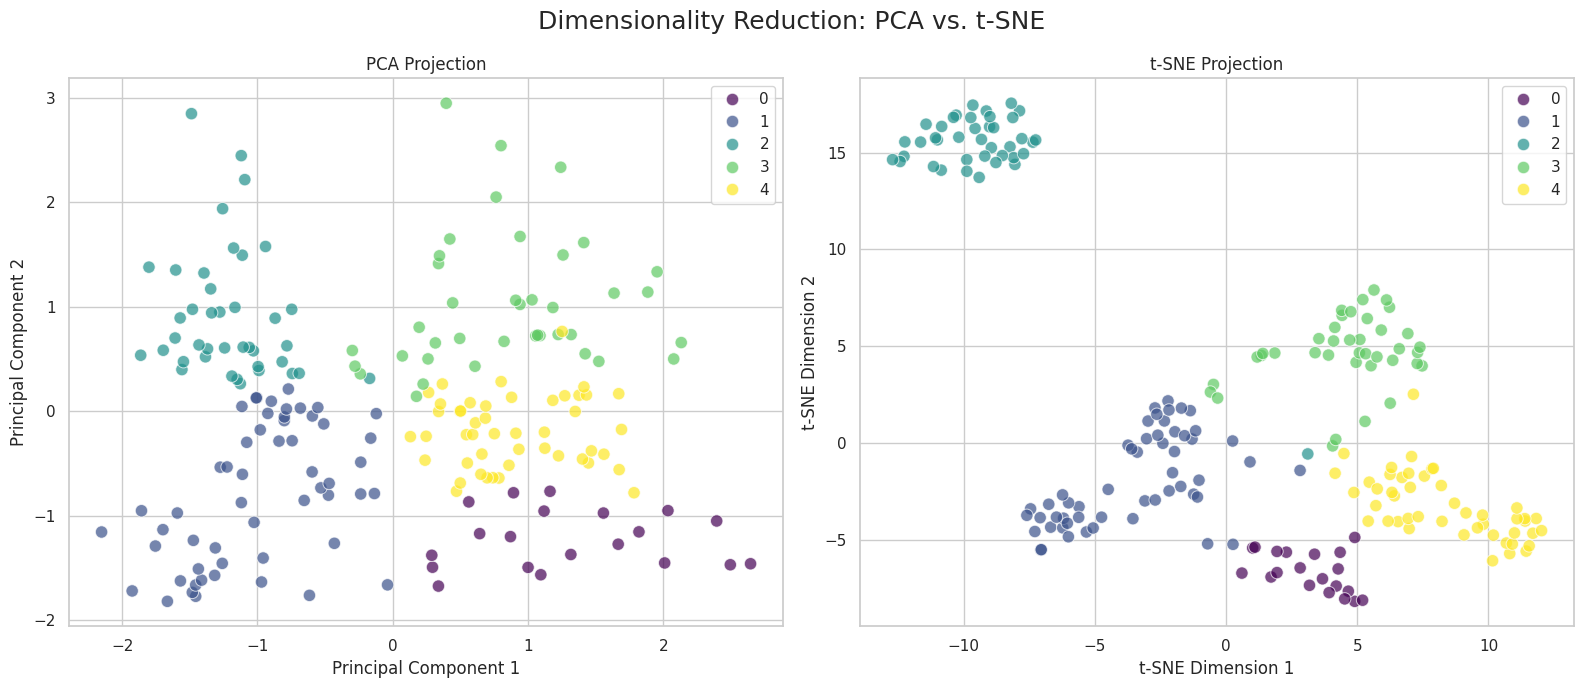

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# 1. Prepare K-Means labels (using our optimal K=5 on X3_scaled)
kmeans_final = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
labels = kmeans_final.fit_predict(X3_scaled)

# 2. PCA Projection (Linear)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X3_scaled)

# 3. t-SNE Projection (Non-linear)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X3_scaled)

# 4. Side-by-Side Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Dimensionality Reduction: PCA vs. t-SNE', fontsize=18)

# PCA Plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="viridis", ax=axes[0], s=80, alpha=0.7)
axes[0].set_title('PCA Projection')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# t-SNE Plot
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette="viridis", ax=axes[1], s=80, alpha=0.7)
axes[1].set_title('t-SNE Projection')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.show()

## Dimensionality Reduction: PCA vs. t-SNE for Cluster Visualization

**Which reveals cluster structure more clearly?**
In this analysis, **t-SNE reveals the cluster structure more clearly than PCA.** While PCA effectively preserves the global variance and the overall orientation of the data, it projects high-dimensional data onto a linear plane, which often leads to "smearing" or overlapping clusters if the data relationships are complex or non-linear. In contrast, t-SNE prioritizes the preservation of local neighborhoods, which allows it to create distinct, separated "islands" of clusters, making the separation between our customer segments visually undeniable and easier to interpret.



**When would you prefer t-SNE over PCA for visualization?**
You should prefer t-SNE over PCA whenever your primary goal is the **visual interpretability of cluster separation** in complex, non-linear datasets.

* **Use PCA when:** You need to understand the global structure, require a mathematically deterministic output (that is, the result does not change every time you run it), or you intend to use the transformed components as features for a subsequent machine learning model.
* **Use t-SNE when:** You are conducting Exploratory Data Analysis (EDA) and need to verify if distinct, non-linear clusters exist that PCA might have "smeared" together. It is an excellent tool for showing stakeholders that "yes, these groups are mathematically distinct," even if the internal distances between those groups in the t-SNE plot do not have the same rigid geometric meaning that they do in PCA.

# **PART D — FINAL DASHBOARD, CLUSTER PROFILES & WRITTEN REPORT(STEPS 16–18)**

# Step-16 Complete 6-Chart Clustering Dashboard


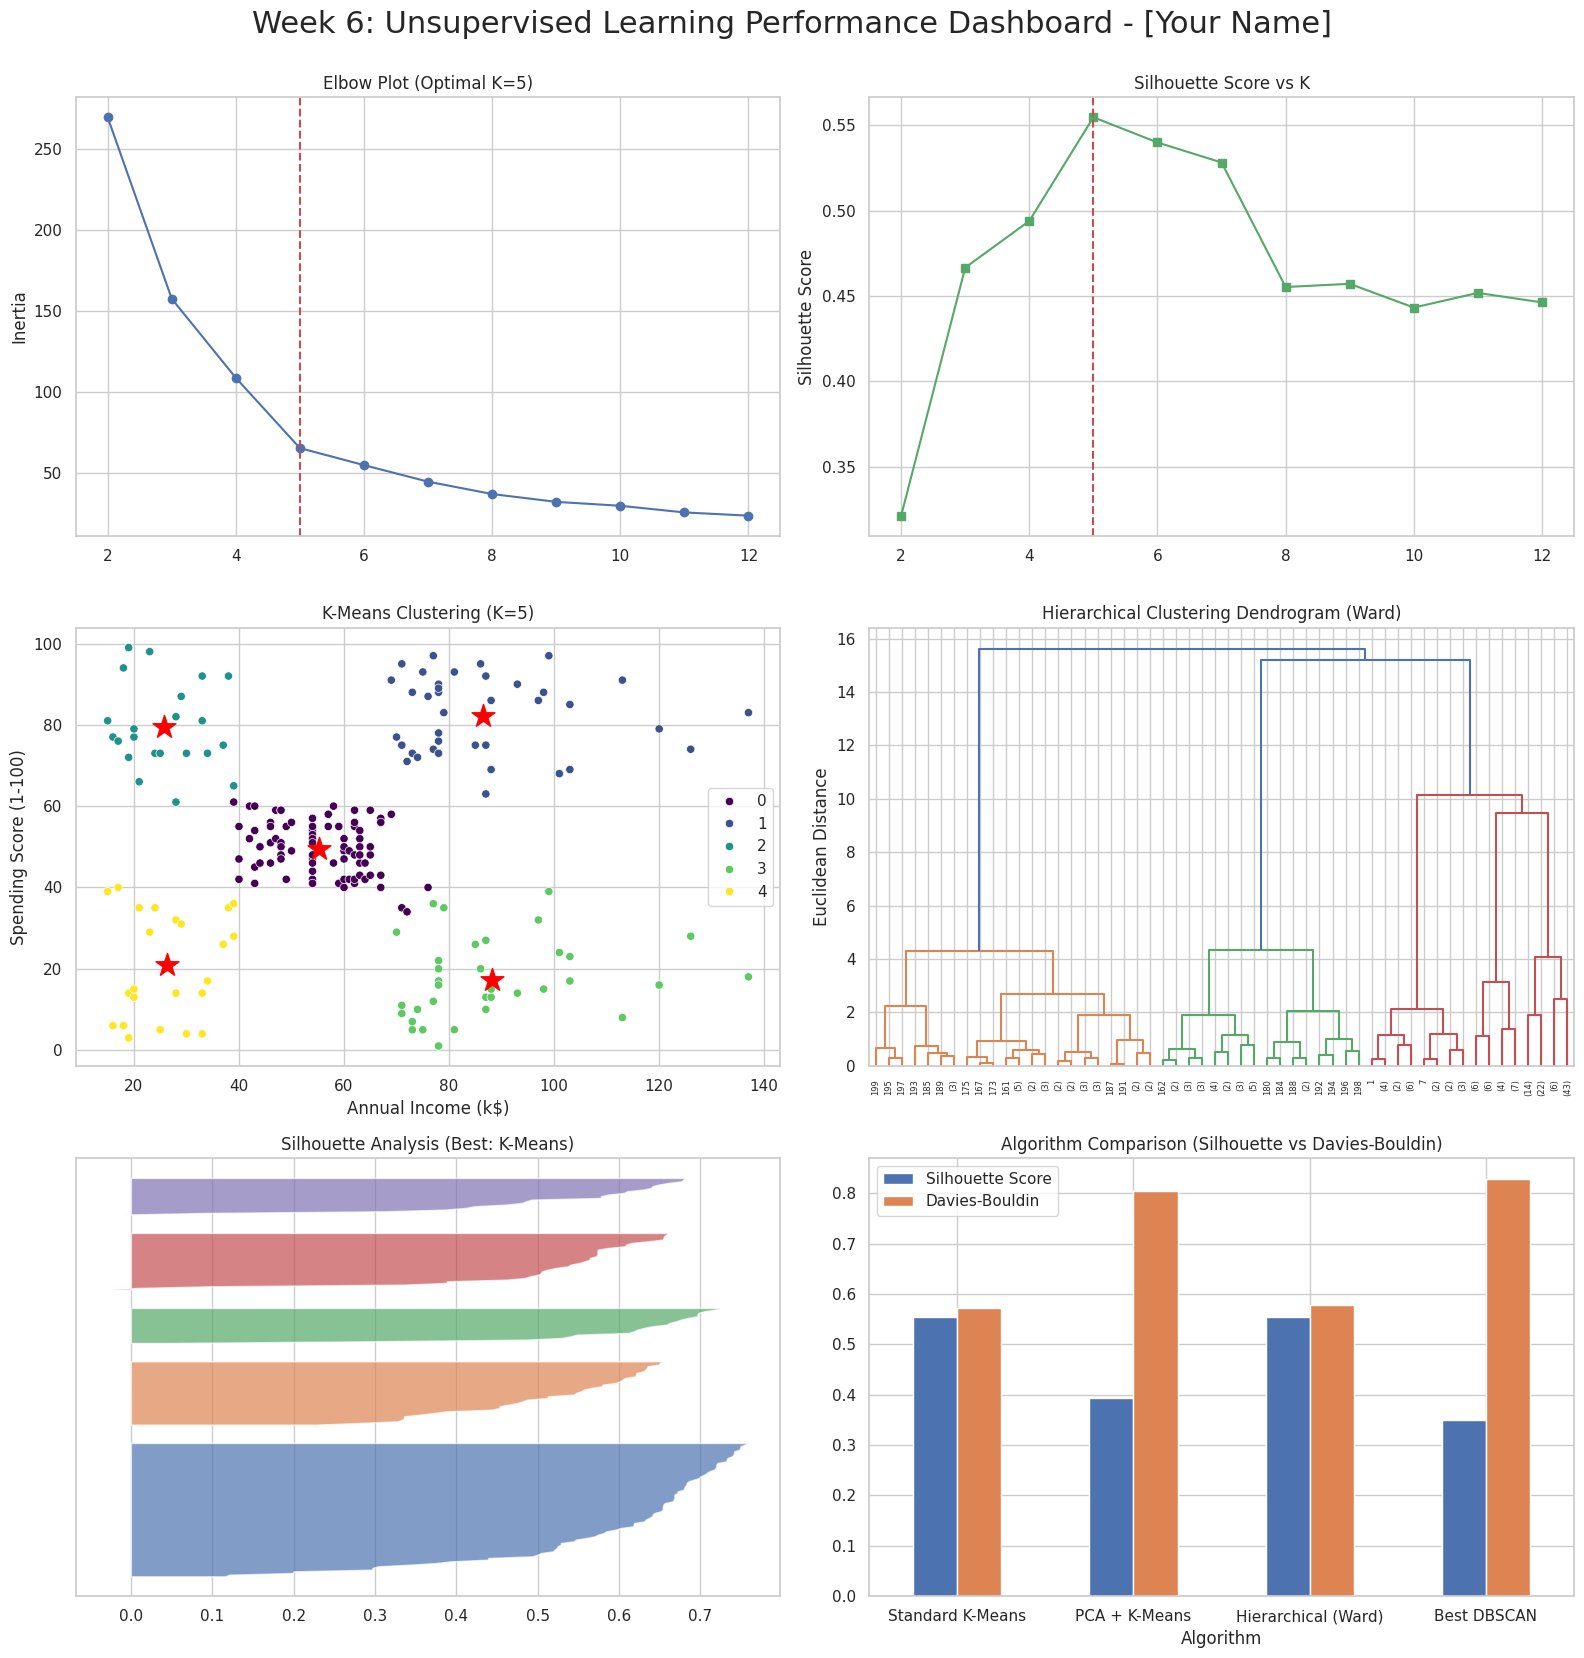

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples

# --- STEP 6: Metrics Loop (Generates results_df) ---
inertia_values, sil_scores, db_scores, ch_scores = [], [], [], []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X2_scaled)
    inertia_values.append(km.inertia_)
    sil_scores.append(silhouette_score(X2_scaled, labels))
    db_scores.append(davies_bouldin_score(X2_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X2_scaled, labels))

results_df = pd.DataFrame({
    'K': K_range,
    'Inertia (WCSS)': inertia_values,
    'Silhouette Score': sil_scores,
    'Davies-Bouldin Index': db_scores,
    'Calinski-Harabasz Index': ch_scores
})

# --- STEP 16: Refined Dashboard ---
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Week 6: Unsupervised Learning Performance Dashboard - [Your Name]', fontsize=22, y=0.95)
axes = axes.flatten()

# Chart 1: Elbow Plot
axes[0].plot(results_df['K'], results_df['Inertia (WCSS)'], marker='o', color='b')
axes[0].axvline(x=5, color='r', linestyle='--')
axes[0].set_title('Elbow Plot (Optimal K=5)')
axes[0].set_ylabel('Inertia')

# Chart 2: Silhouette Score vs K
axes[1].plot(results_df['K'], results_df['Silhouette Score'], marker='s', color='g')
axes[1].axvline(x=5, color='r', linestyle='--')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_ylabel('Silhouette Score')

# Chart 3: 2D Scatter (Best K-Means)
sns.scatterplot(data=X2, x=X2.columns[0], y=X2.columns[1], hue=labels_kmeans, palette='viridis', ax=axes[2])
axes[2].scatter(unscaled_centroids[:, 0], unscaled_centroids[:, 1], marker='*', s=300, c='red', label='Centroids')
axes[2].set_title('K-Means Clustering (K=5)')

# Chart 4: Dendrogram (Ward)
Z = sch.linkage(X2_scaled, method='ward')
sch.dendrogram(Z, truncate_mode='level', p=5, ax=axes[3])
axes[3].set_title('Hierarchical Clustering Dendrogram (Ward)')
axes[3].set_ylabel('Euclidean Distance')

# Chart 5: Silhouette Analysis (K-Means)
sample_silhouette = silhouette_samples(X2_scaled, labels_kmeans)
y_lower = 10
for i in range(5):
    ith_vals = np.sort(sample_silhouette[labels_kmeans == i])
    size = ith_vals.shape[0]
    y_upper = y_lower + size
    axes[4].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_vals, alpha=0.7)
    y_lower = y_upper + 10
axes[4].set_title('Silhouette Analysis (Best: K-Means)')
axes[4].set_yticks([])

# Chart 6: Algorithm Comparison
final_df.set_index('Algorithm')[['Silhouette Score', 'Davies-Bouldin']].plot(kind='bar', ax=axes[5], rot=0)
axes[5].set_title('Algorithm Comparison (Silhouette vs Davies-Bouldin)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('week6_dashboard.png', dpi=150)
plt.show()

# Step-17 Generate Cluster Profiles & Save Best Model

In [30]:
# 1. Add cluster labels to the original DataFrame
df['Cluster'] = labels_kmeans

# 2. Select ONLY numeric columns to avoid the TypeError
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Ensure we don't try to calculate statistics on the 'Cluster' label itself
if 'Cluster' in numeric_cols:
    numeric_cols.remove('Cluster')

# 3. Create the comprehensive cluster profile table
# We group by 'Cluster' and perform aggregations on the numeric columns only
profile = df.groupby('Cluster')[numeric_cols].agg(['mean', 'median', 'min', 'max'])

print("\n--- Comprehensive Cluster Profile Table ---")
display(profile)

# 4. Optional: Add readable segment names
segment_names = {
    0: 'Standard Shoppers',
    1: 'High-Value Youth',
    2: 'Frugal Seniors',
    3: 'Budget Spenders',
    4: 'Luxury Savers'
}
# Note: You can view this by using a cross-tab or just referencing the mapping later


--- Comprehensive Cluster Profile Table ---


Age                Annual Income (k$)                  \
              mean median min max               mean median min  max   
Cluster                                                                
0        42.716049   46.0  18  70          55.296296   54.0  39   76   
1        32.692308   32.0  27  40          86.538462   79.0  69  137   
2        25.272727   23.5  18  35          25.727273   24.5  15   39   
3        41.114286   42.0  19  59          88.200000   85.0  70  137   
4        45.217391   46.0  19  67          26.304348   25.0  15   39   

        Spending Score (1-100)                 
                          mean median min max  
Cluster                                        
0                    49.518519   50.0  34  61  
1                    82.128205   83.0  63  97  
2                    79.363636   77.0  61  99  
3                    17.114286   16.0   1  39  
4                    20.913043   17.0   3  40

# Step-18 Written Analysis Report — 7 Required Sections